In [0]:
# Load US Flights 2023 data into Spark DataFrame
flights_df = spark.read.table("workspace.default.us_flights_2023")
geolocation_df = spark.read.table('workspace.default.airports_geolocation')
cancelled_df = spark.read.table('workspace.default.cancelled_diverted_2023')
weather_df = spark.read.table('workspace.default.weather_meteo_by_airport')

# Take a sample (first 5 rows) to verify loading
sample_df = flights_df.limit(5)
display(sample_df)

FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age
2023-12-04,1,United Air Lines Inc.,N37471,LAX,"Los Angeles, CA",Afternoon,3,1,Low <5min,DEN,"Denver, CO",-9,Low <5min,135,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,11
2023-12-04,1,United Air Lines Inc.,N47512,FLL,"Fort Lauderdale, FL",Morning,-5,0,Low <5min,ORD,"Chicago, IL",-19,Low <5min,189,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5
2023-12-04,1,United Air Lines Inc.,N810UA,SFO,"San Francisco, CA",Morning,-11,0,Low <5min,RDM,"Bend/Redmond, OR",-16,Low <5min,93,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26
2023-12-04,1,United Air Lines Inc.,N810UA,SBA,"Santa Barbara, CA",Morning,-6,0,Low <5min,SFO,"San Francisco, CA",-19,Low <5min,58,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26
2023-12-04,1,United Air Lines Inc.,N897UA,SDF,"Louisville, KY",Afternoon,-4,0,Low <5min,DEN,"Denver, CO",-4,Low <5min,187,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,17


In [0]:
%sql
-- check count of each "time" (Can we use the time column to join with weather data? - NO)
-- SELECT COUNT(*) FROM weather_meteo_by_airport GROUP BY time

-- but Notice that every time" occurs exactly 364 times in the weather_meteo_by_airport table
-- SELECT COUNT(*) FROM weather_meteo_by_airport GROUP BY time HAVING COUNT(*) != '364'

-- Check if any other column can be used or pair of columns can be used to perform the join - Seem to only differ in airport_id
-- SELECT * FROM weather_meteo_by_airport WHERE time = '2023-01-01'

-- check if time-airport_id pairs are unique (they are)
SELECT time, airport_id, COUNT(*) AS pair_count FROM weather_meteo_by_airport GROUP BY time, airport_id HAVING COUNT(*) > 1


time,airport_id,pair_count


In [0]:
# flights_with_weather_df = flights_df.join(weather_df, on = flights_df['FlightDate'] == weather_df['time'], how = "left")
flights_with_weather_df = flights_df.join(weather_df, on=(flights_df["FlightDate"] == weather_df["time"]) & (flights_df["Dep_Airport"] == weather_df["airport_id"]), how="left")
display(flights_with_weather_df.limit(5))


FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id
2023-12-04,1,United Air Lines Inc.,N37471,LAX,"Los Angeles, CA",Afternoon,3,1,Low <5min,DEN,"Denver, CO",-9,Low <5min,135,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,11,2023-12-04,15.3,10.6,22.2,0.0,0.0,317.0,6.5,1019.3,LAX
2023-12-04,1,United Air Lines Inc.,N47512,FLL,"Fort Lauderdale, FL",Morning,-5,0,Low <5min,ORD,"Chicago, IL",-19,Low <5min,189,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5,2023-12-04,25.1,21.7,28.3,0.0,0.0,264.0,7.2,1016.2,FLL
2023-12-04,1,United Air Lines Inc.,N810UA,SFO,"San Francisco, CA",Morning,-11,0,Low <5min,RDM,"Bend/Redmond, OR",-16,Low <5min,93,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,10.6,17.2,0.0,0.0,336.0,6.1,1024.1,SFO
2023-12-04,1,United Air Lines Inc.,N810UA,SBA,"Santa Barbara, CA",Morning,-6,0,Low <5min,SFO,"San Francisco, CA",-19,Low <5min,58,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,6.7,22.2,0.0,0.0,340.0,4.0,1019.4,SBA
2023-12-04,1,United Air Lines Inc.,N897UA,SDF,"Louisville, KY",Afternoon,-4,0,Low <5min,DEN,"Denver, CO",-4,Low <5min,187,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,17,2023-12-04,5.6,2.2,10.6,4.6,0.0,355.0,6.8,1014.4,SDF


In [0]:
print("Shape before join:", (flights_df.count(), len(flights_df.columns)))
print("Shape after join:", (flights_with_weather_df.count(), len(flights_with_weather_df.columns)))
print("The Data has", flights_with_weather_df.select("Airline").distinct().count(), "unique Airlines") 


Shape before join: (6743404, 24)
Shape after join: (6743404, 34)
The Data has 15 unique Airlines


In [0]:
from pyspark.sql.functions import when

# Create new column 'Delayed (> 15 min)' (1 if Dep_Delay > 15, else 0)
flights_delayed_df = flights_with_weather_df.withColumn(
    "Delayed (> 15 min)",
    when(flights_with_weather_df["Arr_Delay"] > 15, 1).otherwise(0)
)
display(flights_delayed_df.limit(5))

FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id,Delayed (> 15 min)
2023-12-04,1,United Air Lines Inc.,N37471,LAX,"Los Angeles, CA",Afternoon,3,1,Low <5min,DEN,"Denver, CO",-9,Low <5min,135,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,11,2023-12-04,15.3,10.6,22.2,0.0,0.0,317.0,6.5,1019.3,LAX,0
2023-12-04,1,United Air Lines Inc.,N47512,FLL,"Fort Lauderdale, FL",Morning,-5,0,Low <5min,ORD,"Chicago, IL",-19,Low <5min,189,Short Haul >1500Mi,0,0,0,0,0,BOEING,737 NG,5,2023-12-04,25.1,21.7,28.3,0.0,0.0,264.0,7.2,1016.2,FLL,0
2023-12-04,1,United Air Lines Inc.,N810UA,SFO,"San Francisco, CA",Morning,-11,0,Low <5min,RDM,"Bend/Redmond, OR",-16,Low <5min,93,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,10.6,17.2,0.0,0.0,336.0,6.1,1024.1,SFO,0
2023-12-04,1,United Air Lines Inc.,N810UA,SBA,"Santa Barbara, CA",Morning,-6,0,Low <5min,SFO,"San Francisco, CA",-19,Low <5min,58,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,26,2023-12-04,13.9,6.7,22.2,0.0,0.0,340.0,4.0,1019.4,SBA,0
2023-12-04,1,United Air Lines Inc.,N897UA,SDF,"Louisville, KY",Afternoon,-4,0,Low <5min,DEN,"Denver, CO",-4,Low <5min,187,Short Haul >1500Mi,0,0,0,0,0,AIRBUS,A319,17,2023-12-04,5.6,2.2,10.6,4.6,0.0,355.0,6.8,1014.4,SDF,0


In [0]:
# Display summary statistics for numeric columns only
numeric_columns = [
    "Day_Of_Week", "Dep_Delay", "Arr_Delay", "Flight_Duration",
    "Delay_Carrier", "Delay_Weather", "Delay_NAS", "Delay_Security", "Delay_LastAircraft",
    "Aicraft_age", "tavg", "tmin", "tmax", "prcp", "snow", "wdir", "wspd", "pres",
    "Delayed (> 15 min)"
]

display(flights_delayed_df.select(numeric_columns).describe())

# How is there a flight duration of 0 minutes?

summary,Day_Of_Week,Dep_Delay,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Aicraft_age,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,Delayed (> 15 min)
count,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404,6743404
mean,3.9827932599025657,12.200986623373003,6.62715150983094,140.29777854033364,5.169803559152025,0.7428504950912032,2.566956984929273,0.030648764333265514,5.681107642371716,13.48062640174013,16.810826409021658,11.822923845315204,22.165465067746744,2.4378081455765304,3.2204973927114557,188.81902003795116,12.476340420965185,1015.729985435165,0.19866479896503308
stddev,2.001761815808881,55.079361141759804,57.07892145230851,72.87215749288374,36.45732361905642,14.353928078253157,15.004842221861123,1.6289230717178067,30.44646891849584,7.891494668265463,9.153797310963377,9.177309907630553,9.74868514264257,8.253368735721025,31.00108086015336,111.30652075147289,5.640855128779134,6.2422875399772355,0.3989951380969996
min,1,-99,-119,0,0,0,0,0,0,1,-39.1,-76.0,-35.0,0.0,0.0,0.0,0.0,968.6,0
max,7,4413,4405,795,3957,1860,1708,1460,3581,57,42.2,37.2,50.0,571.5,1780.0,360.0,59.4,1051.0,1


In [0]:
import pandas as pd

# Select key metrics for presentation (fewer columns for clarity)
presentation_columns = [
    "Dep_Delay", "Arr_Delay", "Flight_Duration",
    "Aicraft_age", "tavg", "prcp", "snow", "wspd"
]

# Get summary statistics and convert to pandas
summary_stats = flights_delayed_df.select(presentation_columns).toPandas().describe()

# Round to 2 decimal places for cleaner presentation
summary_stats = summary_stats.round(2)

# Transpose for better readability in presentations (variables as rows)
summary_transposed = summary_stats.T

# Reset index to make variable names an actual column
summary_transposed = summary_transposed.reset_index()
summary_transposed = summary_transposed.rename(columns={'index': 'Variable'})

# Display with cleaner formatting
display(summary_transposed)

Variable,count,mean,std,min,25%,50%,75%,max
Dep_Delay,6743404.0,12.2,55.08,-99.0,-5.0,-2.0,9.0,4413.0
Arr_Delay,6743404.0,6.63,57.08,-119.0,-15.0,-6.0,9.0,4405.0
Flight_Duration,6743404.0,140.3,72.87,0.0,87.0,124.0,171.0,795.0
Aicraft_age,6743404.0,13.48,7.89,1.0,7.0,12.0,20.0,57.0
tavg,6743404.0,16.81,9.15,-39.1,10.4,17.8,23.9,42.2
prcp,6743404.0,2.44,8.25,0.0,0.0,0.0,0.5,571.5
snow,6743404.0,3.22,31.0,0.0,0.0,0.0,0.0,1780.0
wspd,6743404.0,12.48,5.64,0.0,8.4,11.5,15.5,59.4


In [0]:
# Filter for flights with 0 minute duration
zero_duration_flights = flights_delayed_df.filter(flights_delayed_df["Flight_Duration"] == 0)

print(f"Number of flights with 0 duration: {zero_duration_flights.count()}")
display(zero_duration_flights.limit(20))

Number of flights with 0 duration: 1


FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_CityName,DepTime_label,Dep_Delay,Dep_Delay_Tag,Dep_Delay_Type,Arr_Airport,Arr_CityName,Arr_Delay,Arr_Delay_Type,Flight_Duration,Distance_type,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aicraft_age,time,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,airport_id,Delayed (> 15 min)
2023-05-21,7,Republic Airways,N231JQ,LGA,"New York, NY",Afternoon,37,1,Medium >15min,BNA,"Nashville, TN",0,Low <5min,0,Short Haul >1500Mi,0,0,0,0,0,EMBRAER,170/175,16,2023-05-21,17.5,13.0,21.0,0.3,0.0,317.0,10.8,1014.3,LGA,0


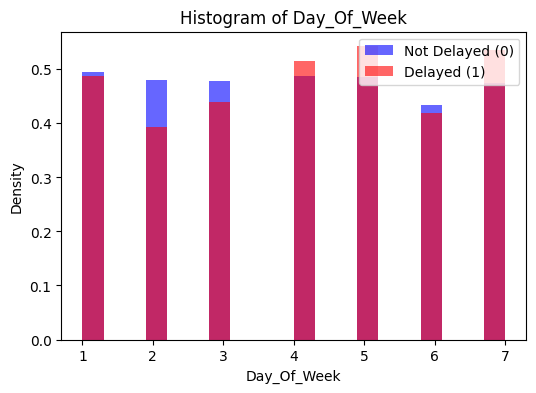

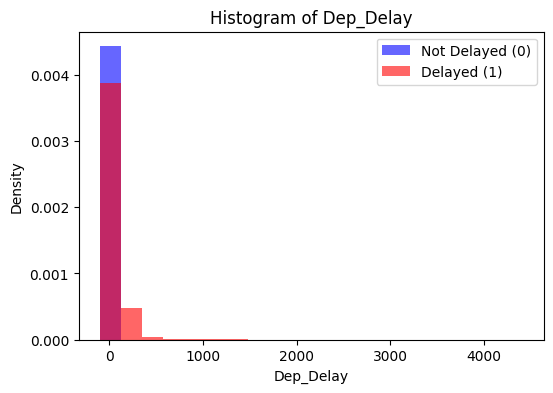

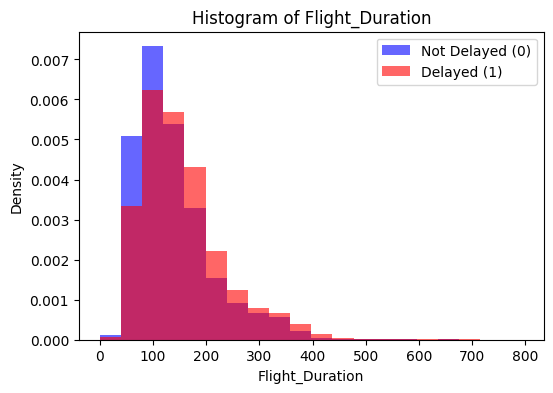

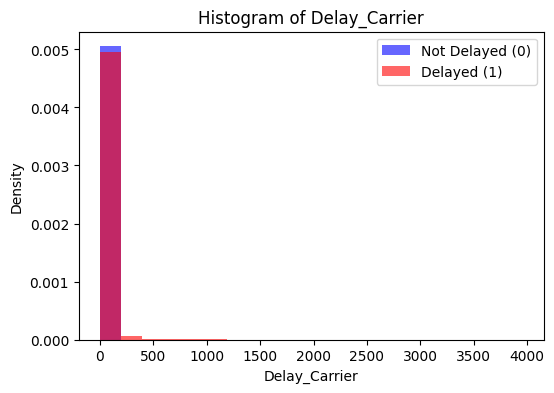

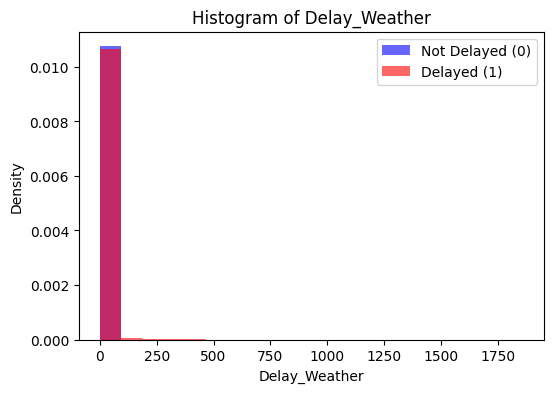

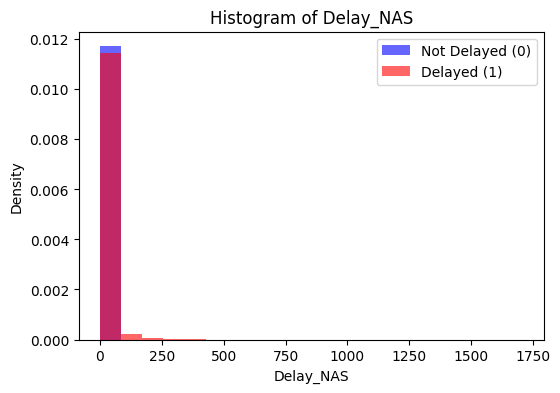

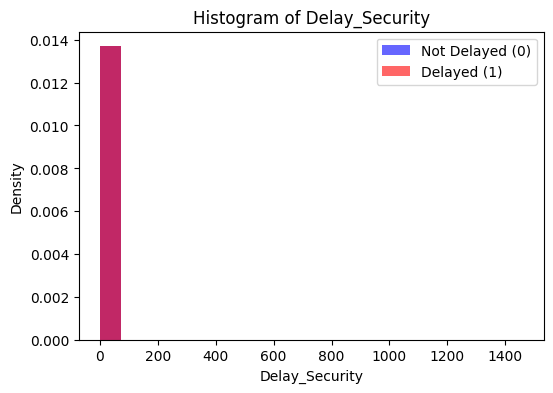

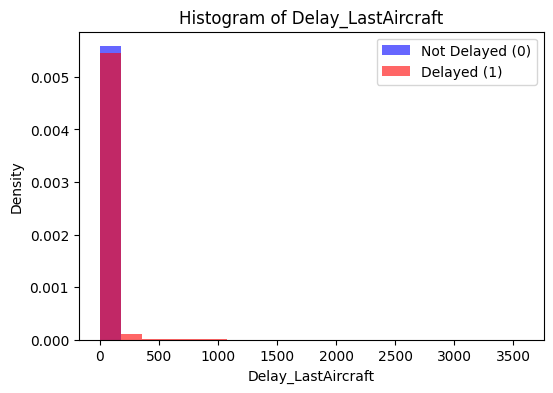

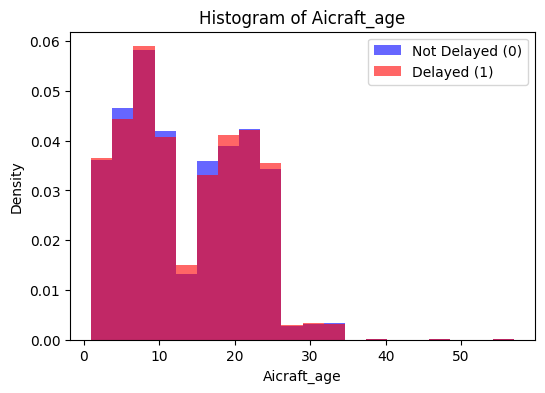

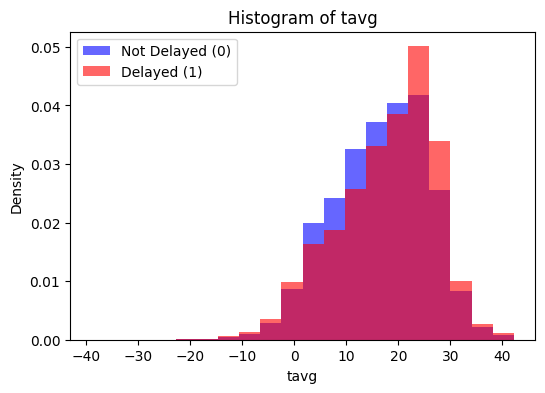

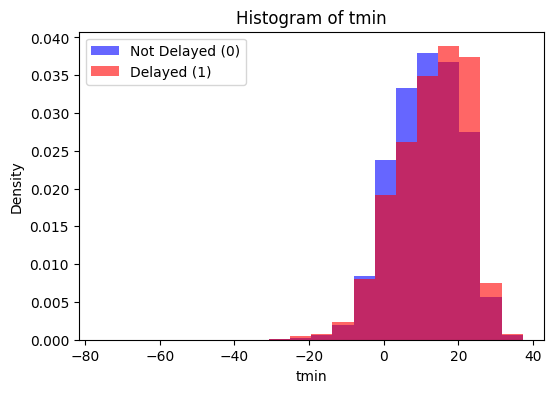

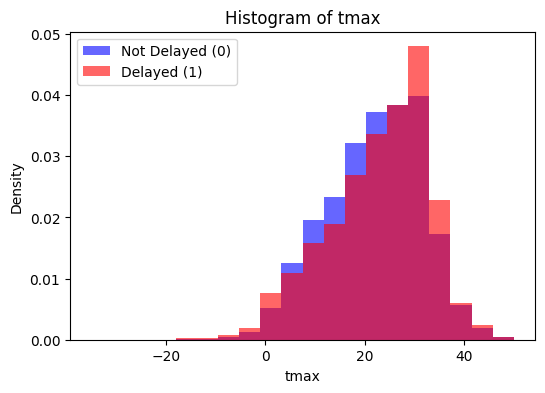

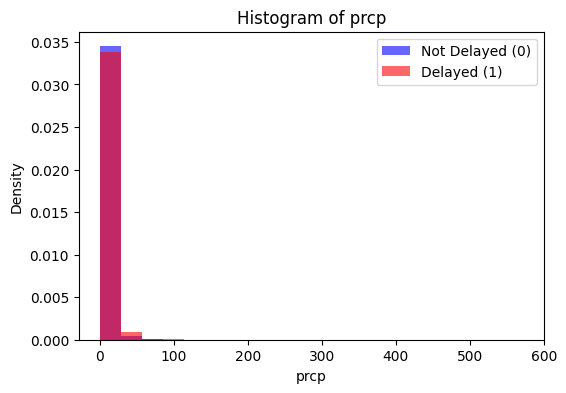

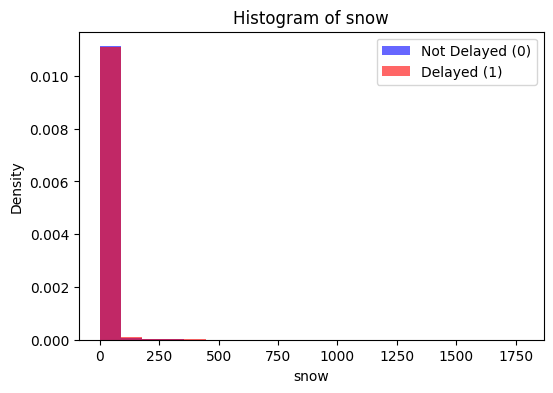

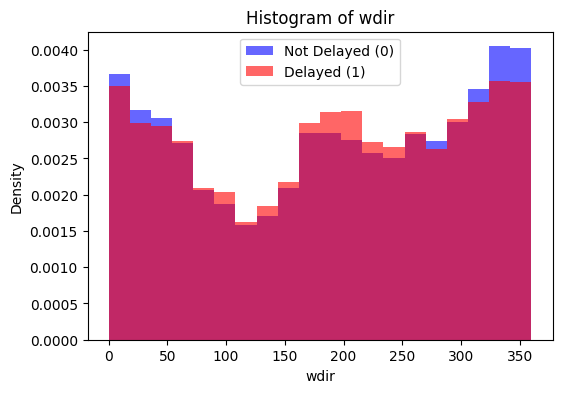

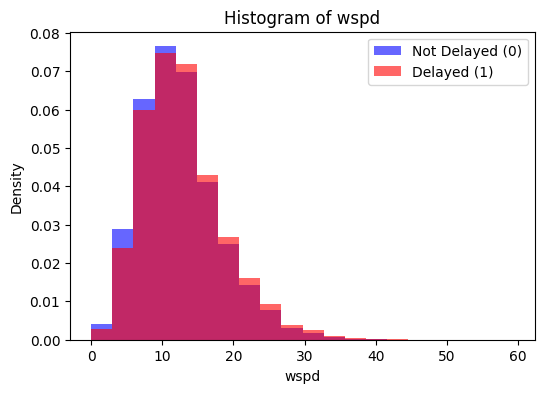

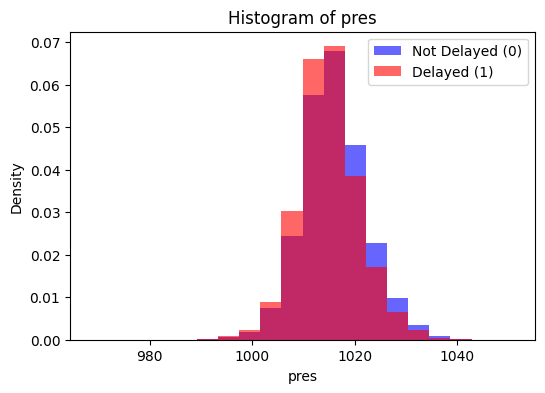

In [0]:
import matplotlib.pyplot as plt
import numpy as np
from pyspark.sql.functions import col

# Variables to plot histograms (numeric only)
numeric_columns = [
    "Day_Of_Week", "Dep_Delay", "Flight_Duration",
    "Delay_Carrier", "Delay_Weather", "Delay_NAS", "Delay_Security", "Delay_LastAircraft", "Aicraft_age",
    "tavg", "tmin", "tmax", "prcp", "snow", "wdir", "wspd", "pres"
]

# SAMPLE DATA?
# Collect a sample for speed (change limit as needed)
# sample_data = flights_delayed_df.select(numeric_columns + ["Delayed (> 15 min)"]).sample(fraction=0.1, seed=42).toPandas()
sample_data = flights_delayed_df.select(numeric_columns + ["Delayed (> 15 min)"]).toPandas()

# Plot histograms for each numeric column using consistent bins
for col_name in numeric_columns:
    plt.figure(figsize=(6,4))
    delayed_mask = sample_data["Delayed (> 15 min)"] == 1
    not_delayed_mask = sample_data["Delayed (> 15 min)"] == 0
    # Compute bin edges from full data
    data_min = sample_data[col_name].min()
    data_max = sample_data[col_name].max()
    bins = np.linspace(data_min, data_max, 21)  # 20 equal-width bins
    plt.hist(
        sample_data[col_name][not_delayed_mask], bins=bins, density=True, alpha=0.6, color='blue', label='Not Delayed (0)'
    )
    plt.hist(
        sample_data[col_name][delayed_mask], bins=bins, density=True, alpha=0.6, color='red', label='Delayed (1)'
    )
    plt.title(f"Histogram of {col_name}")
    plt.xlabel(col_name)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

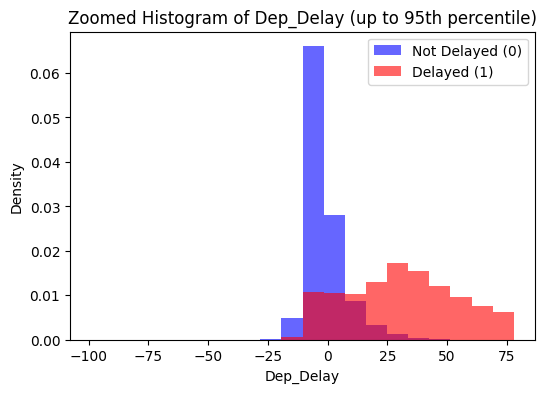

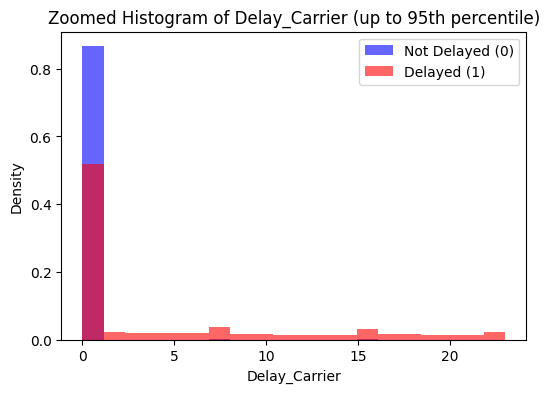

Skipping Delay_Weather: insufficient data variation


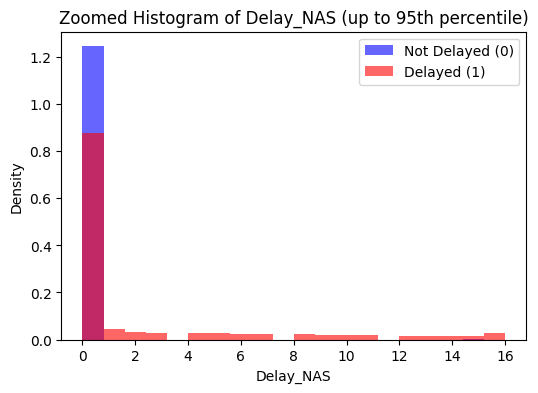

Skipping Delay_Security: insufficient data variation


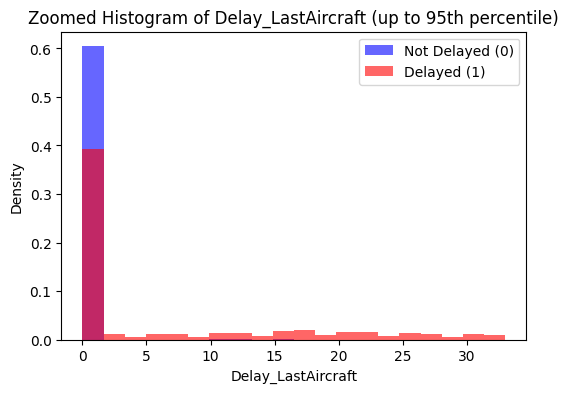

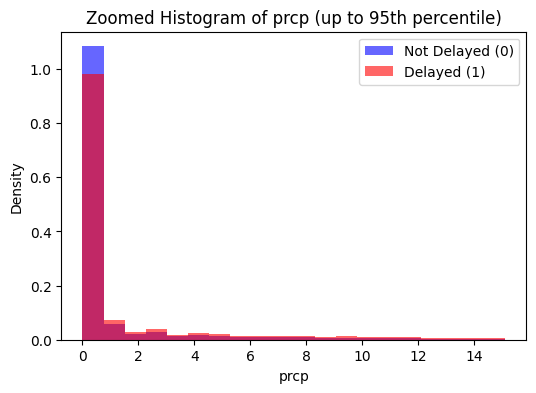

Skipping snow: insufficient data variation


In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Same variables as Cell 9 (skewed variables)
skewed_columns = [
    "Dep_Delay", "Delay_Carrier", "Delay_Weather", "Delay_NAS", 
    "Delay_Security", "Delay_LastAircraft", "prcp", "snow"
]

# Use the same sample data from Cell 7
zoom_sample_data = sample_data.copy()

for col_name in skewed_columns:
    delayed_mask = zoom_sample_data["Delayed (> 15 min)"] == 1
    not_delayed_mask = zoom_sample_data["Delayed (> 15 min)"] == 0
    
    # Get data for both groups
    not_delayed_data = zoom_sample_data[col_name][not_delayed_mask]
    delayed_data = zoom_sample_data[col_name][delayed_mask]
    all_data = zoom_sample_data[col_name]
    
    # Zoom in by using 95th percentile as upper limit (focus on bulk of data)
    data_min = all_data.min()
    data_max = all_data.quantile(0.95)  # 95th percentile to exclude extreme outliers
    
    # Skip if there's no meaningful range (avoids divide-by-zero)
    if data_min == data_max or data_max - data_min < 0.001:
        print(f"Skipping {col_name}: insufficient data variation")
        continue
    
    # Filter data to zoomed range
    not_delayed_zoomed = not_delayed_data[(not_delayed_data >= data_min) & (not_delayed_data <= data_max)]
    delayed_zoomed = delayed_data[(delayed_data >= data_min) & (delayed_data <= data_max)]
    
    # Skip if no data after filtering
    if len(not_delayed_zoomed) == 0 and len(delayed_zoomed) == 0:
        print(f"Skipping {col_name}: no data in zoomed range")
        continue
    
    plt.figure(figsize=(6,4))
    
    # Create bins for zoomed range
    bins = np.linspace(data_min, data_max, 21)
    
    plt.hist(
        not_delayed_zoomed, bins=bins, density=True, alpha=0.6, 
        color='blue', label='Not Delayed (0)'
    )
    plt.hist(
        delayed_zoomed, bins=bins, density=True, alpha=0.6, 
        color='red', label='Delayed (1)'
    )
    
    plt.title(f"Zoomed Histogram of {col_name} (up to 95th percentile)")
    plt.xlabel(col_name)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

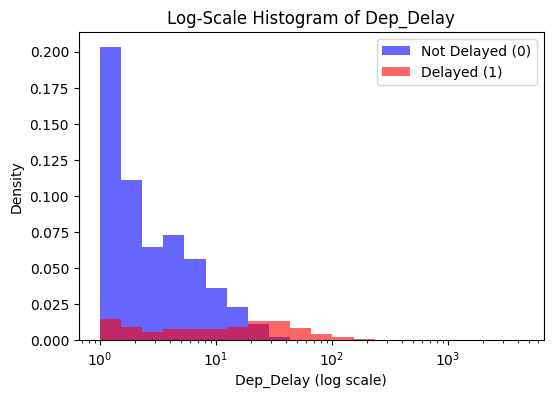

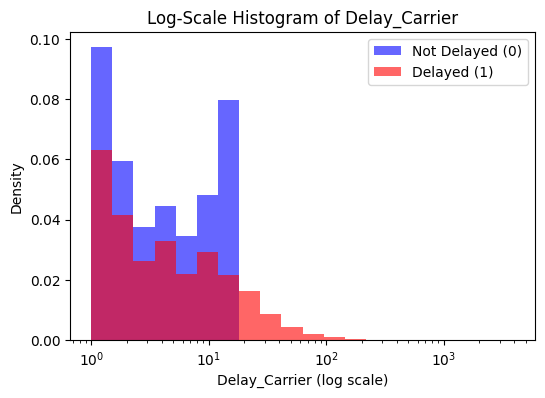

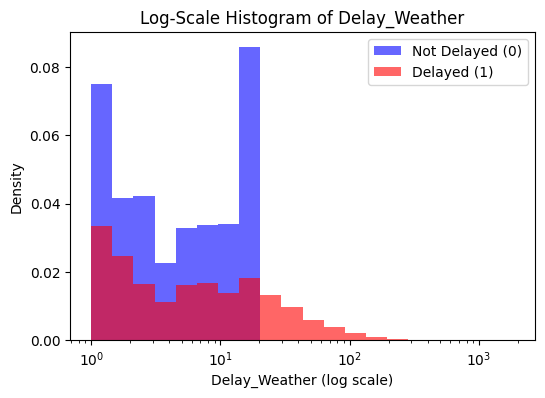

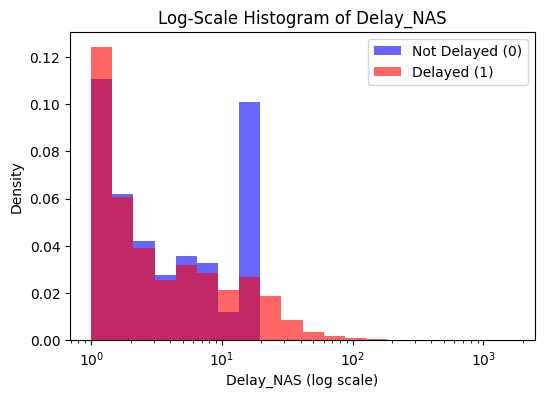

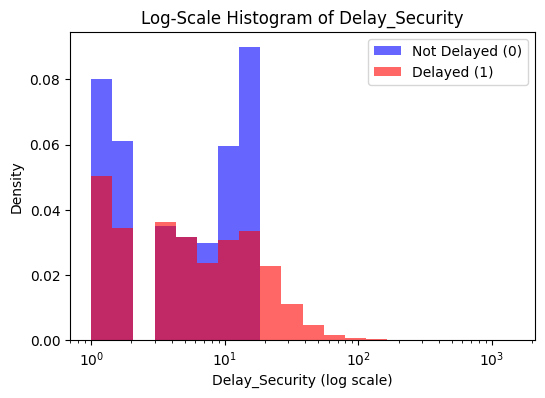

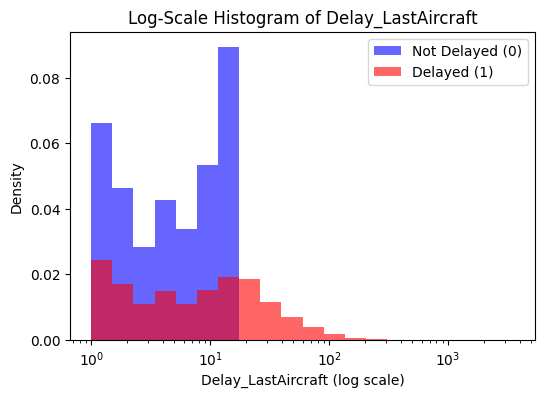

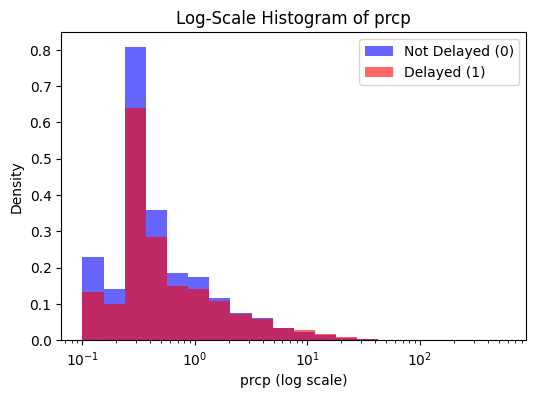

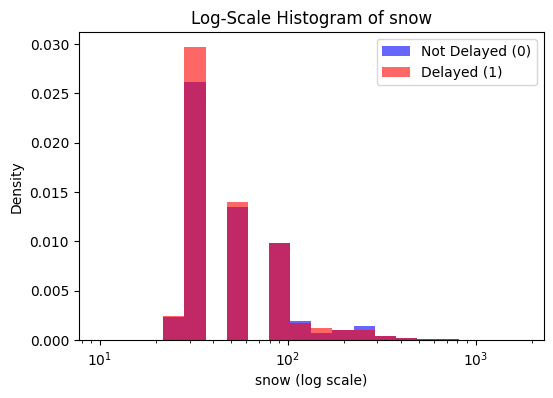

In [0]:
# Graphs are a bit weird because all values <= 0 are not included
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Highly skewed variables that benefit from log scale
skewed_columns = [
    "Dep_Delay", "Delay_Carrier", "Delay_Weather", "Delay_NAS", 
    "Delay_Security", "Delay_LastAircraft", "prcp", "snow"
]

# Use the same sample data from previous cell
log_sample_data = sample_data.copy()

for col_name in skewed_columns:
    plt.figure(figsize=(6,4))
    delayed_mask = log_sample_data["Delayed (> 15 min)"] == 1
    not_delayed_mask = log_sample_data["Delayed (> 15 min)"] == 0
    
    # Get data for both groups
    not_delayed_data = log_sample_data[col_name][not_delayed_mask]
    delayed_data = log_sample_data[col_name][delayed_mask]
    
    # Filter out non-positive values for log scale (need to do this before computing bins)
    not_delayed_positive = not_delayed_data[not_delayed_data > 0]
    delayed_positive = delayed_data[delayed_data > 0]
    
    if len(not_delayed_positive) > 0 or len(delayed_positive) > 0:
        # Compute log-scale bin edges from ALL positive data
        all_positive = pd.concat([not_delayed_positive, delayed_positive])
        if len(all_positive) > 0:
            data_min = max(all_positive.min(), 0.001)  # Avoid log(0)
            data_max = all_positive.max()
            bins = np.logspace(np.log10(data_min), np.log10(data_max), 21)
            
            # Plot both groups with same bins and density normalization
            plt.hist(
                not_delayed_positive, bins=bins, density=True, alpha=0.6, 
                color='blue', label='Not Delayed (0)'
            )
            plt.hist(
                delayed_positive, bins=bins, density=True, alpha=0.6, 
                color='red', label='Delayed (1)'
            )
            
            plt.xscale('log')
            plt.title(f"Log-Scale Histogram of {col_name}")
            plt.xlabel(f"{col_name} (log scale)")
            plt.ylabel("Density")
            plt.legend()
            plt.show()
    else:
        print(f"Skipping {col_name}: no positive values to plot")

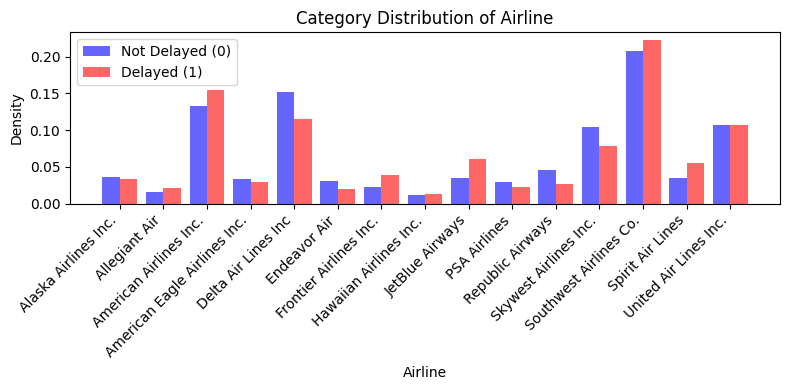

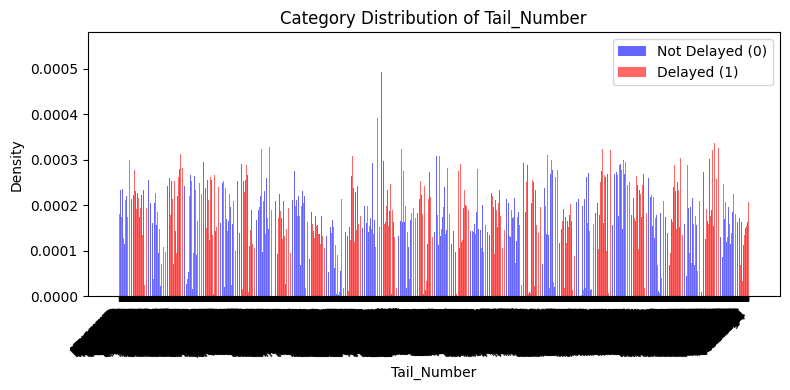

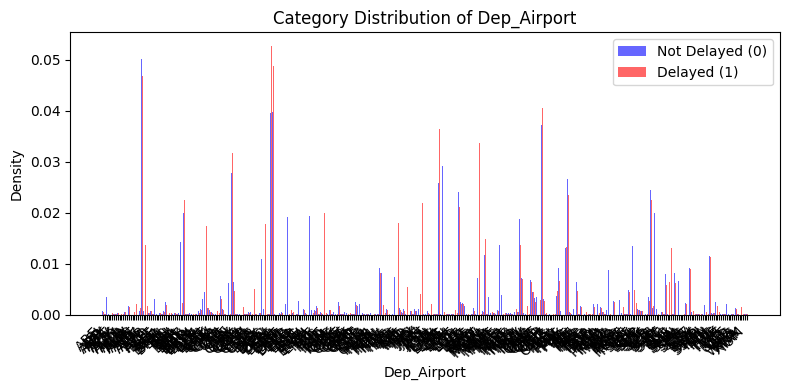

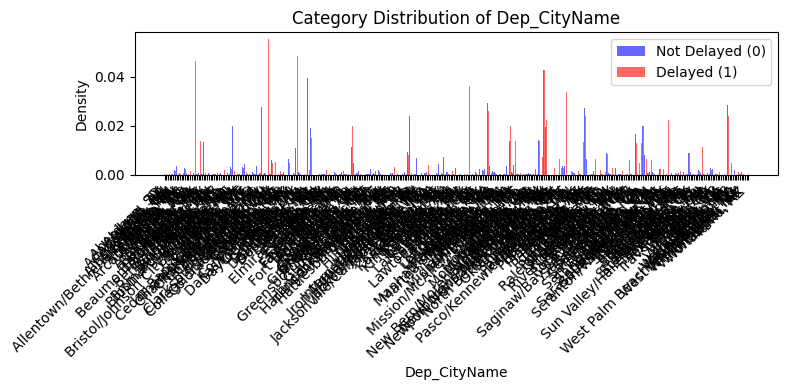

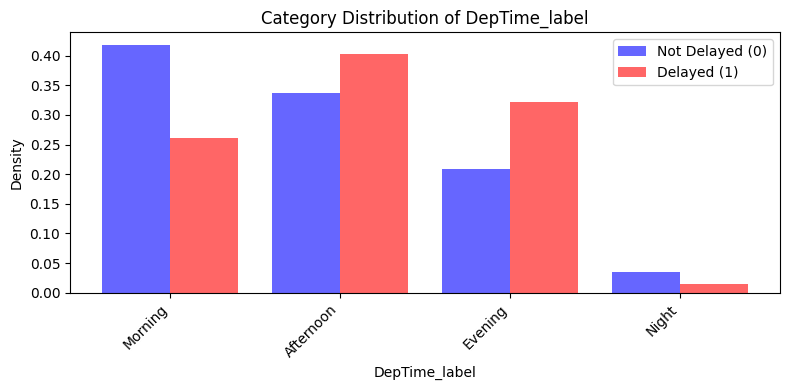

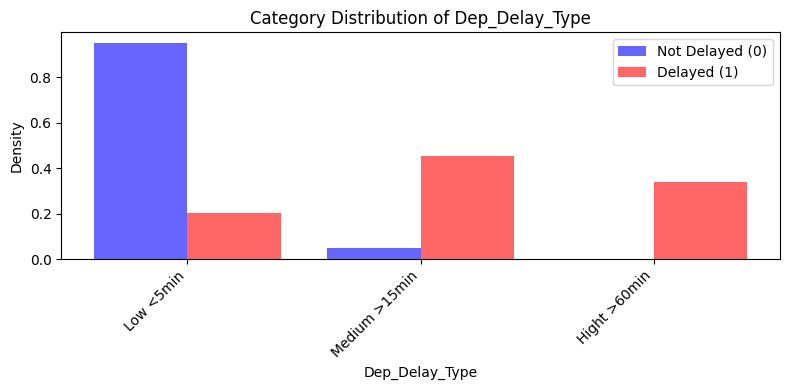

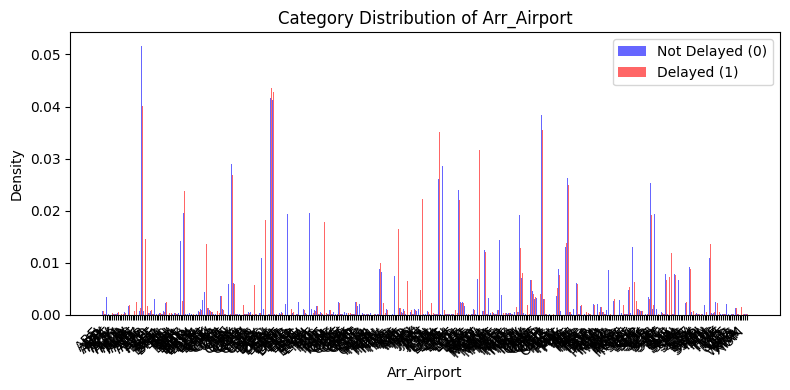

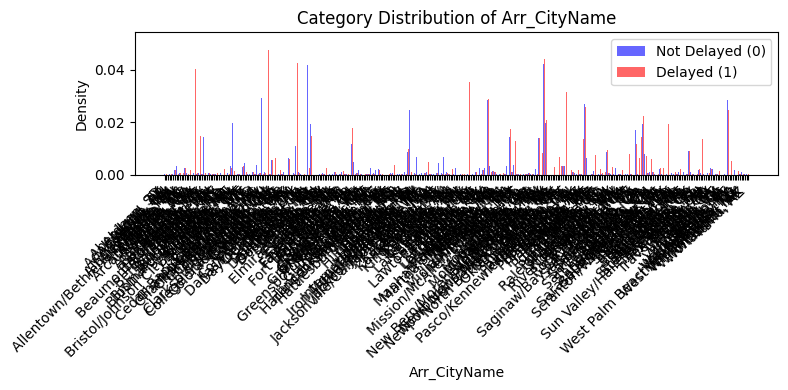

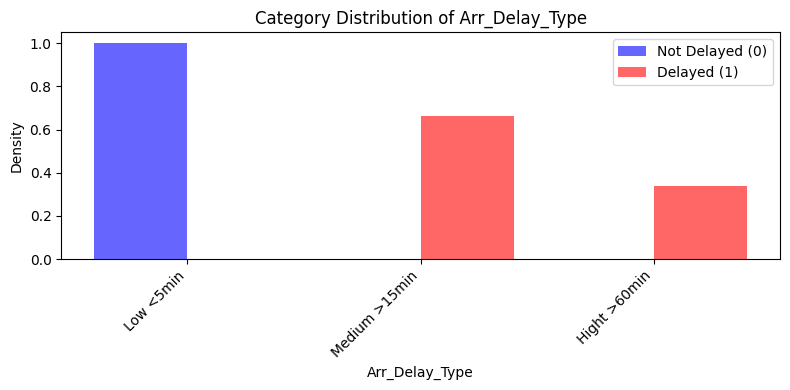

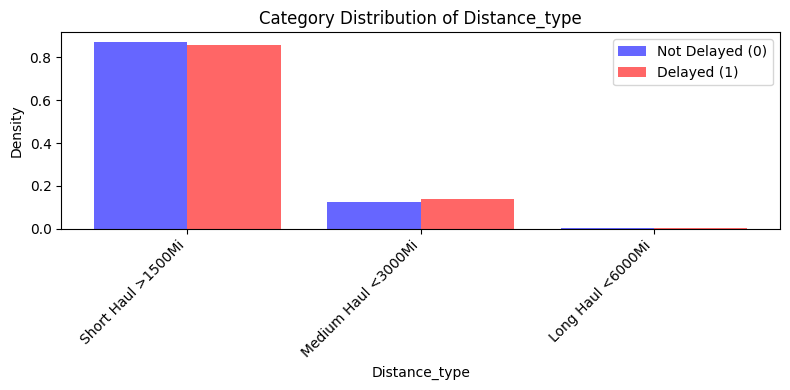

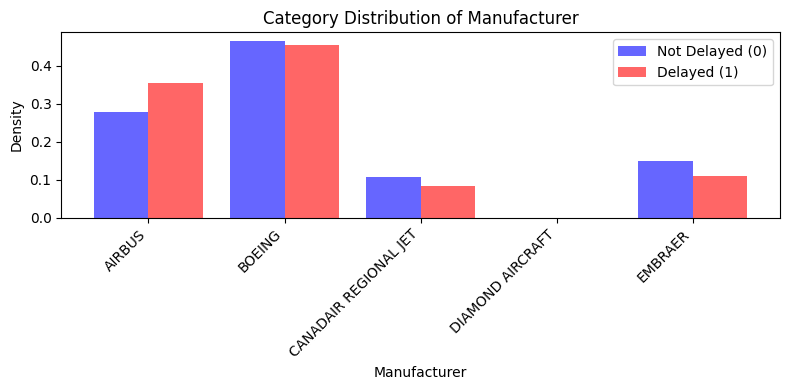

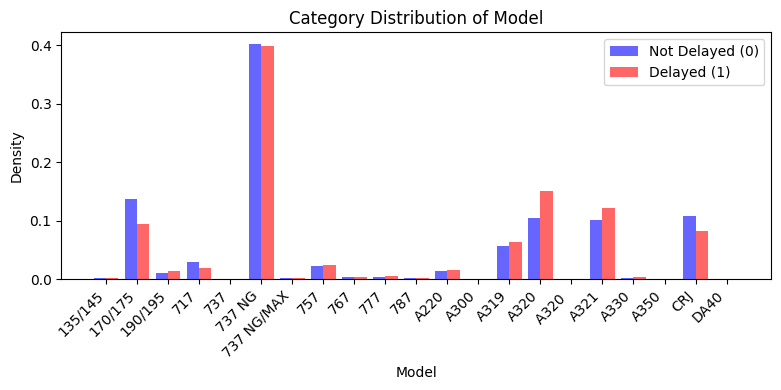

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# List of categorical columns to visualize
categorical_columns = [
    "Airline", "Tail_Number", "Dep_Airport", "Dep_CityName",
    "DepTime_label", "Dep_Delay_Type", "Arr_Airport", "Arr_CityName",
    "Arr_Delay_Type", "Distance_type", "Manufacturer", "Model"
]

# Define custom orderings for columns with inherent order
custom_orders = {
    "DepTime_label": ["Morning", "Afternoon", "Evening", "Night"],
    "Dep_Delay_Type": ["Low <5min", "Medium >15min", "Hight >60min"],
    "Arr_Delay_Type": ["Low <5min", "Medium >15min", "Hight >60min"],
    "Distance_type": ["Short Haul >1500Mi", "Medium Haul <3000Mi", "Long Haul <6000Mi"]
}

# Use random sampling for better category coverage
# cat_sample = flights_delayed_df.select(categorical_columns + ["Delayed (> 15 min)"]).sample(fraction=0.1, seed=42).toPandas()
cat_sample = flights_delayed_df.select(categorical_columns + ["Delayed (> 15 min)"]).toPandas()

for cat_col in categorical_columns:
    plt.figure(figsize=(8,4))
    delayed_mask = cat_sample["Delayed (> 15 min)"] == 1
    not_delayed_mask = cat_sample["Delayed (> 15 min)"] == 0
    delayed_counts = cat_sample[delayed_mask][cat_col].value_counts(normalize=True)
    not_delayed_counts = cat_sample[not_delayed_mask][cat_col].value_counts(normalize=True)
    
    # Use custom order if defined, otherwise sort alphabetically
    if cat_col in custom_orders:
        # Use predefined order, filtering to only categories that exist in data
        categories = [c for c in custom_orders[cat_col] if c in delayed_counts.index or c in not_delayed_counts.index]
    else:
        categories = list(set(delayed_counts.index).union(not_delayed_counts.index))
        categories.sort()
    
    bar_width = 0.4
    x = np.arange(len(categories))
    plt.bar(x - bar_width/2, [not_delayed_counts.get(c,0) for c in categories],
            width=bar_width, color='blue', alpha=0.6, label='Not Delayed (0)')
    plt.bar(x + bar_width/2, [delayed_counts.get(c,0) for c in categories],
            width=bar_width, color='red', alpha=0.6, label='Delayed (1)')
    plt.xticks(x, categories, rotation=45, ha='right')
    plt.title(f'Category Distribution of {cat_col}')
    plt.xlabel(cat_col)
    plt.ylabel('Density')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [0]:
from pyspark.sql.functions import avg

# Calculate average wind direction per departure airport
avg_wdir_by_airport = flights_delayed_df.groupBy("Dep_Airport").agg(
    avg("wdir").alias("avg_wdir_airport")
)

# Join back to main dataframe
flights_with_wdir_diff = flights_delayed_df.join(
    avg_wdir_by_airport, 
    on="Dep_Airport", 
    how="left"
)

# Create new column for wind direction difference
flights_with_wdir_diff = flights_with_wdir_diff.withColumn(
    "wdir_diff_from_airport_avg",
    flights_with_wdir_diff["wdir"] - flights_with_wdir_diff["avg_wdir_airport"]
)

# Show sample of the new column
print(f"Total flights with wind data: {flights_with_wdir_diff.filter(flights_with_wdir_diff['wdir'].isNotNull()).count()}")
display(flights_with_wdir_diff.select("Dep_Airport", "wdir", "avg_wdir_airport", "wdir_diff_from_airport_avg").limit(20))

Total flights with wind data: 6743404


Dep_Airport,wdir,avg_wdir_airport,wdir_diff_from_airport_avg
LAX,317.0,228.2104103817747,88.7895896182253
FLL,264.0,143.2809184265293,120.7190815734707
SFO,336.0,251.07578868769835,84.92421131230165
SBA,340.0,192.25643200452362,147.74356799547638
SDF,355.0,184.1166941718058,170.8833058281942
DEN,220.0,183.89325475017594,36.10674524982406
ORD,283.0,173.64207024710768,109.35792975289232
EWR,290.0,224.47383889641216,65.52616110358784
IAH,353.0,157.9223992680629,195.0776007319371
LAX,317.0,228.2104103817747,88.7895896182253


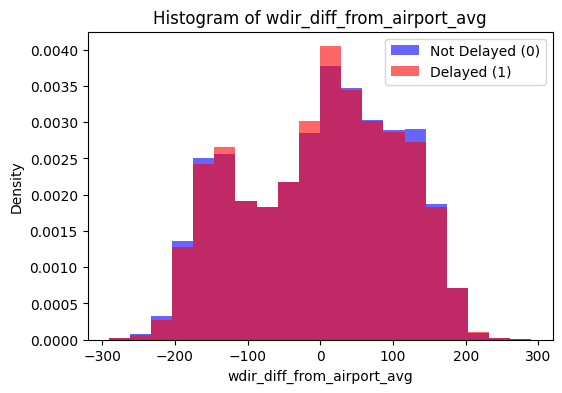

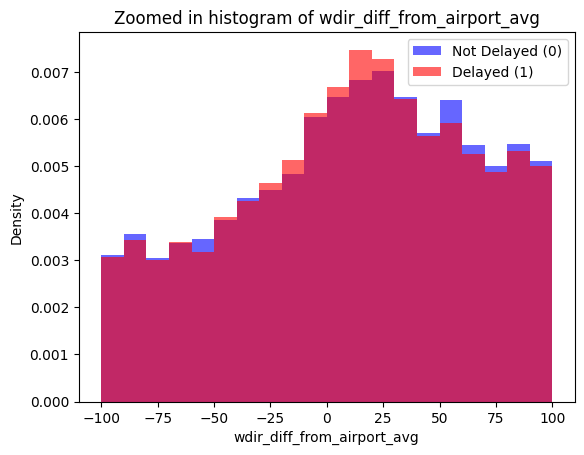

In [0]:
import matplotlib.pyplot as plt
import numpy as np

# Sample the data with the new wind direction difference column
wdir_sample = flights_with_wdir_diff.select(["wdir_diff_from_airport_avg", "Delayed (> 15 min)"]).toPandas()

# Create histogram for wind direction difference
plt.figure(figsize=(6,4))
delayed_mask = wdir_sample["Delayed (> 15 min)"] == 1
not_delayed_mask = wdir_sample["Delayed (> 15 min)"] == 0

# Compute bin edges from full data
data_min = wdir_sample["wdir_diff_from_airport_avg"].min()
data_max = wdir_sample["wdir_diff_from_airport_avg"].max()
bins = np.linspace(data_min, data_max, 21)  # 20 equal-width bins

plt.hist(
    wdir_sample["wdir_diff_from_airport_avg"][not_delayed_mask], 
    bins=bins, density=True, alpha=0.6, color='blue', label='Not Delayed (0)'
)
plt.hist(
    wdir_sample["wdir_diff_from_airport_avg"][delayed_mask], 
    bins=bins, density=True, alpha=0.6, color='red', label='Delayed (1)'
)

plt.title(f"Histogram of wdir_diff_from_airport_avg")
plt.xlabel("wdir_diff_from_airport_avg")
plt.ylabel("Density")
plt.legend()
plt.show()


bins = np.linspace(-100, 100, 21)

plt.hist(
    wdir_sample["wdir_diff_from_airport_avg"][not_delayed_mask], 
    bins=bins, density=True, alpha=0.6, color='blue', label='Not Delayed (0)'
)
plt.hist(
    wdir_sample["wdir_diff_from_airport_avg"][delayed_mask], 
    bins=bins, density=True, alpha=0.6, color='red', label='Delayed (1)'
)

plt.title(f"Zoomed in histogram of wdir_diff_from_airport_avg")
plt.xlabel("wdir_diff_from_airport_avg")
plt.ylabel("Density")
plt.legend()
plt.show()

In [0]:
# Databricks manages the connection
# spark.stop()

Number of airports appearing on both plots: 9
Airports on both plots: ['BQN', 'CKB', 'HTS', 'MVY', 'PSM', 'PVU', 'SCK', 'SMX', 'USA']


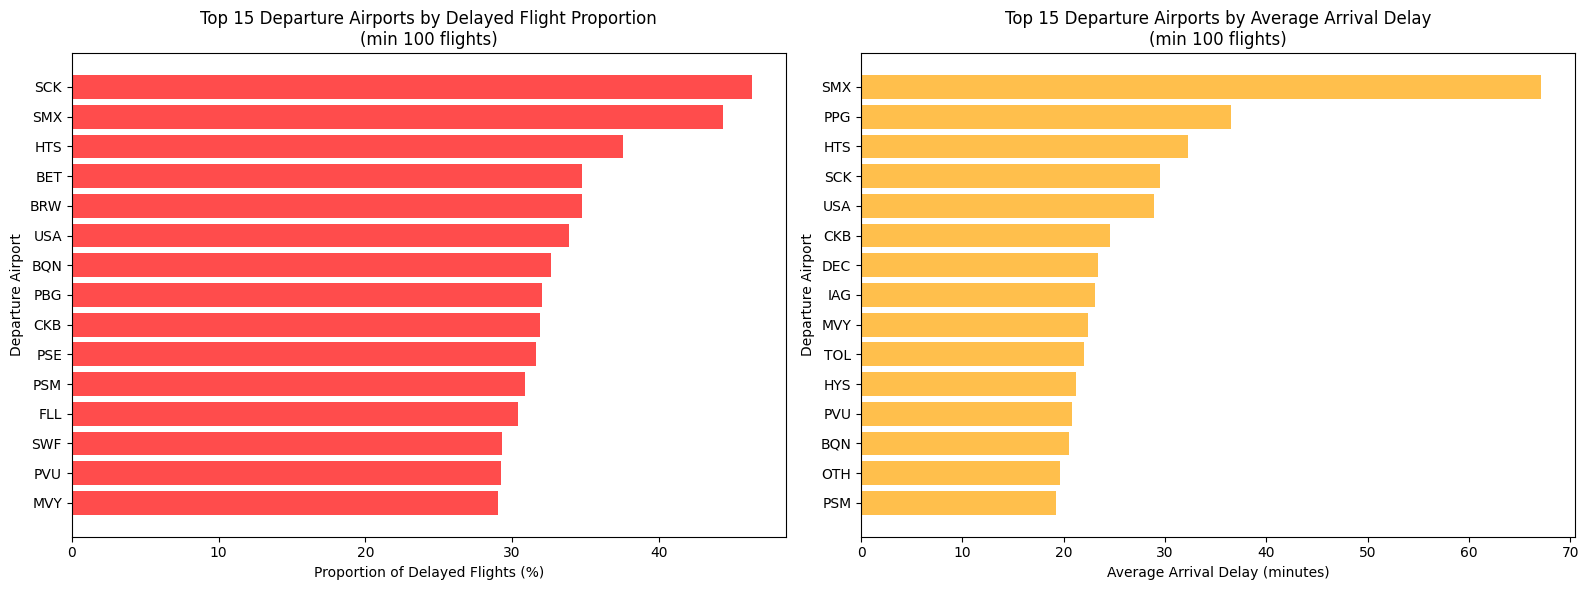

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, avg, count, col

# 1. Top departure airports by proportion of delayed flights
delayed_by_airport = flights_delayed_df.groupBy("Dep_Airport").agg(
    spark_sum("Delayed (> 15 min)").alias("delayed_count"),
    count("*").alias("total_flights")
).withColumn(
    "delay_proportion",
    col("delayed_count") / col("total_flights")
).filter(col("total_flights") >= 100).orderBy(col("delay_proportion").desc()).limit(15).toPandas()

# 2. Top departure airports by average arrival delay
avg_delay_by_airport = flights_delayed_df.groupBy("Dep_Airport").agg(
    avg("Arr_Delay").alias("avg_arrival_delay"),
    count("*").alias("total_flights")
).filter(col("total_flights") >= 100).orderBy(col("avg_arrival_delay").desc()).limit(15).toPandas()

# Calculate overlap between the two lists
airports_in_both = set(delayed_by_airport["Dep_Airport"]) & set(avg_delay_by_airport["Dep_Airport"])
print(f"Number of airports appearing on both plots: {len(airports_in_both)}")
print(f"Airports on both plots: {sorted(airports_in_both)}")

# Visualization 1: Top airports by delayed flight proportion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(delayed_by_airport["Dep_Airport"], delayed_by_airport["delay_proportion"] * 100, color='red', alpha=0.7)
axes[0].set_xlabel("Proportion of Delayed Flights (%)")
axes[0].set_ylabel("Departure Airport")
axes[0].set_title("Top 15 Departure Airports by Delayed Flight Proportion\n(min 100 flights)")
axes[0].invert_yaxis()

# Visualization 2: Top airports by average arrival delay
axes[1].barh(avg_delay_by_airport["Dep_Airport"], avg_delay_by_airport["avg_arrival_delay"], color='orange', alpha=0.7)
axes[1].set_xlabel("Average Arrival Delay (minutes)")
axes[1].set_ylabel("Departure Airport")
axes[1].set_title("Top 15 Departure Airports by Average Arrival Delay\n(min 100 flights)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

Number of airports appearing on both plots: 7
Airports on both plots: ['BQN', 'CKB', 'HTS', 'PVU', 'SCK', 'SMX', 'USA']


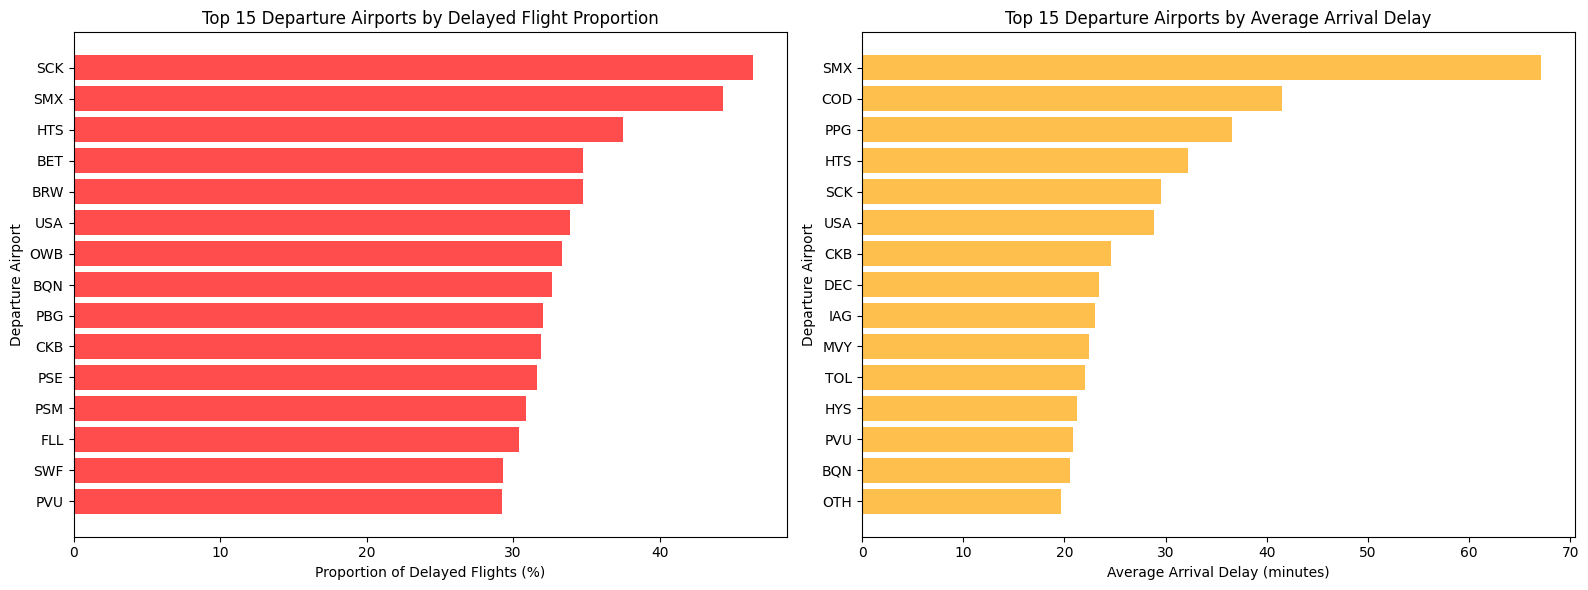

In [0]:
import matplotlib.pyplot as plt
from pyspark.sql.functions import sum as spark_sum, avg, count, col

# 1. Top departure airports by proportion of delayed flights
delayed_by_airport = flights_delayed_df.groupBy("Dep_Airport").agg(
    spark_sum("Delayed (> 15 min)").alias("delayed_count"),
    count("*").alias("total_flights")
).withColumn(
    "delay_proportion",
    col("delayed_count") / col("total_flights")
).orderBy(col("delay_proportion").desc()).limit(15).toPandas()

# 2. Top departure airports by average arrival delay
avg_delay_by_airport = flights_delayed_df.groupBy("Dep_Airport").agg(
    avg("Arr_Delay").alias("avg_arrival_delay"),
    count("*").alias("total_flights")
).orderBy(col("avg_arrival_delay").desc()).limit(15).toPandas()

# Calculate overlap between the two lists
airports_in_both = set(delayed_by_airport["Dep_Airport"]) & set(avg_delay_by_airport["Dep_Airport"])
print(f"Number of airports appearing on both plots: {len(airports_in_both)}")
print(f"Airports on both plots: {sorted(airports_in_both)}")

# Visualization 1: Top airports by delayed flight proportion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(delayed_by_airport["Dep_Airport"], delayed_by_airport["delay_proportion"] * 100, color='red', alpha=0.7)
axes[0].set_xlabel("Proportion of Delayed Flights (%)")
axes[0].set_ylabel("Departure Airport")
axes[0].set_title("Top 15 Departure Airports by Delayed Flight Proportion")
axes[0].invert_yaxis()

# Visualization 2: Top airports by average arrival delay
axes[1].barh(avg_delay_by_airport["Dep_Airport"], avg_delay_by_airport["avg_arrival_delay"], color='orange', alpha=0.7)
axes[1].set_xlabel("Average Arrival Delay (minutes)")
axes[1].set_ylabel("Departure Airport")
axes[1].set_title("Top 15 Departure Airports by Average Arrival Delay")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Cleaning

In [0]:
print("All columns in the joined DataFrame:")
for i, c in enumerate(flights_with_weather_df.columns):
    print(f"{i}: {c}")

All columns in the joined DataFrame:
0: FlightDate
1: Day_Of_Week
2: Airline
3: Tail_Number
4: Dep_Airport
5: Dep_CityName
6: DepTime_label
7: Dep_Delay
8: Dep_Delay_Tag
9: Dep_Delay_Type
10: Arr_Airport
11: Arr_CityName
12: Arr_Delay
13: Arr_Delay_Type
14: Flight_Duration
15: Distance_type
16: Delay_Carrier
17: Delay_Weather
18: Delay_NAS
19: Delay_Security
20: Delay_LastAircraft
21: Manufacturer
22: Model
23: Aicraft_age
24: time
25: tavg
26: tmin
27: tmax
28: prcp
29: snow
30: wdir
31: wspd
32: pres
33: airport_id


In [0]:
from pyspark.sql.functions import col, when, isnan, count, mean as _mean
from pyspark.sql.types import IntegerType, DoubleType

# Drop duplicate columns from join
# Remove redundant columns created during the weather join
cleaned_df = flights_delayed_df.drop("time", "airport_id")

print(f"Number of columns after dropping duplicates: {len(cleaned_df.columns)}")
print("Remaining columns:", cleaned_df.columns)

Number of columns after dropping duplicates: 33
Remaining columns: ['FlightDate', 'Day_Of_Week', 'Airline', 'Tail_Number', 'Dep_Airport', 'Dep_CityName', 'DepTime_label', 'Dep_Delay', 'Dep_Delay_Tag', 'Dep_Delay_Type', 'Arr_Airport', 'Arr_CityName', 'Arr_Delay', 'Arr_Delay_Type', 'Flight_Duration', 'Distance_type', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Manufacturer', 'Model', 'Aicraft_age', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Delayed (> 15 min)']


In [0]:
# Remove rows with Flight_Duration = 0
# Inspect abnormal flights (duration <= 0)
print("\n=== Checking Flight_Duration outliers ===")
flights_with_weather_df.filter(col("Flight_Duration") <= 0).show(5)

zero_duration_count = cleaned_df.filter(col("Flight_Duration") <= 0).count()
print(f"Number of rows with Flight_Duration <= 0: {zero_duration_count}")

# Remove invalid flight durations
before = cleaned_df.count()
cleaned_df = cleaned_df.filter(
    (col("Flight_Duration") > 0) & col("Flight_Duration").isNotNull()
)
print(f"Rows removed: {before - cleaned_df.count()}")


=== Checking Flight_Duration outliers ===
+----------+-----------+----------------+-----------+-----------+------------+-------------+---------+-------------+--------------+-----------+-------------+---------+--------------+---------------+------------------+-------------+-------------+---------+--------------+------------------+------------+-------+-----------+----------+----+----+----+----+----+-----+----+------+----------+
|FlightDate|Day_Of_Week|         Airline|Tail_Number|Dep_Airport|Dep_CityName|DepTime_label|Dep_Delay|Dep_Delay_Tag|Dep_Delay_Type|Arr_Airport| Arr_CityName|Arr_Delay|Arr_Delay_Type|Flight_Duration|     Distance_type|Delay_Carrier|Delay_Weather|Delay_NAS|Delay_Security|Delay_LastAircraft|Manufacturer|  Model|Aicraft_age|      time|tavg|tmin|tmax|prcp|snow| wdir|wspd|  pres|airport_id|
+----------+-----------+----------------+-----------+-----------+------------+-------------+---------+-------------+--------------+-----------+-------------+---------+--------------

In [0]:
# Drop rows with missing target values
cleaned_df = cleaned_df.filter(
    col("Dep_Delay").isNotNull() & col("Arr_Delay").isNotNull()
)

# Remove extreme outliers in delay columns
# Cap unrealistic delays (e.g., more than 24 hours)
cleaned_df = cleaned_df.filter(
    (col("Arr_Delay") < 1440) & (col("Arr_Delay") > -180) &
    (col("Dep_Delay") < 1440) & (col("Dep_Delay") > -180)
)

# Fill missing values in delay cause columns with 0
# If there was no delay, these columns are NULL -> fill with 0
delay_cause_cols = ["Delay_Carrier", "Delay_Weather", "Delay_NAS",
                    "Delay_Security", "Delay_LastAircraft"]

for c in delay_cause_cols:
    cleaned_df = cleaned_df.withColumn(
        c, when(col(c).isNull(), 0).otherwise(col(c))
    )

# Handle missing values in weather columns
# Snow and precipitation: NULL means no snow/rain -> fill with 0
cleaned_df = cleaned_df.withColumn("snow", when(col("snow").isNull(), 0).otherwise(col("snow")))
cleaned_df = cleaned_df.withColumn("prcp", when(col("prcp").isNull(), 0).otherwise(col("prcp")))

# Temperature, pressure, wind: fill with mean
weather_numeric = ["tavg", "tmin", "tmax", "wdir", "wspd", "pres"]

for c in weather_numeric:
    mean_val = cleaned_df.select(_mean(col(c))).collect()[0][0]
    if mean_val is not None:
        cleaned_df = cleaned_df.withColumn(
            c, when(col(c).isNull(), mean_val).otherwise(col(c))
        )

# Handle Aircraft_age (note: typo 'Aicraft_age')
age_mean = cleaned_df.select(_mean(col("Aicraft_age"))).collect()[0][0]
cleaned_df = cleaned_df.withColumn(
    "Aicraft_age",
    when(col("Aicraft_age").isNull() | (col("Aicraft_age") < 0), age_mean)
    .otherwise(col("Aicraft_age"))
)

# Rename Aicraft_age to Aircraft_age to fix typo
cleaned_df = cleaned_df.withColumnRenamed("Aicraft_age", "Aircraft_age")

# Drop duplicate rows
before = cleaned_df.count()
cleaned_df = cleaned_df.dropDuplicates()
print(f"Duplicate rows removed: {before - cleaned_df.count()}")

# Remove redundant columns
cleaned_df = cleaned_df.drop("Dep_Delay_Tag", "Dep_Delay_Type", "Dep_CityName", "Arr_Delay_Type", "Arr_CityName", "Distance_type")

Duplicate rows removed: 31


In [0]:

# Final check
print(f"\n✅ Final shape: ({cleaned_df.count()}, {len(cleaned_df.columns)})")
print(f"✅ Final columns: {cleaned_df.columns}")

# Final missing value check
missing_check = cleaned_df.select([
    count(when(col(c).isNull(), c)).alias(c) for c in cleaned_df.columns
])
print("\n=== Final missing values ===")
missing_check.show(vertical=True, truncate=False)

display(cleaned_df.limit(5))


✅ Final shape: (6742823, 27)
✅ Final columns: ['FlightDate', 'Day_Of_Week', 'Airline', 'Tail_Number', 'Dep_Airport', 'DepTime_label', 'Dep_Delay', 'Arr_Airport', 'Arr_Delay', 'Flight_Duration', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Manufacturer', 'Model', 'Aircraft_age', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Delayed (> 15 min)']

=== Final missing values ===
-RECORD 0-----------------
 FlightDate         | 0   
 Day_Of_Week        | 0   
 Airline            | 0   
 Tail_Number        | 0   
 Dep_Airport        | 0   
 DepTime_label      | 0   
 Dep_Delay          | 0   
 Arr_Airport        | 0   
 Arr_Delay          | 0   
 Flight_Duration    | 0   
 Delay_Carrier      | 0   
 Delay_Weather      | 0   
 Delay_NAS          | 0   
 Delay_Security     | 0   
 Delay_LastAircraft | 0   
 Manufacturer       | 0   
 Model              | 0   
 Aircraft_age       | 0   
 tavg               | 0   
 tmin               |

FlightDate,Day_Of_Week,Airline,Tail_Number,Dep_Airport,DepTime_label,Dep_Delay,Arr_Airport,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aircraft_age,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,Delayed (> 15 min)
2023-12-04,1,United Air Lines Inc.,N77530,PHL,Evening,-7,ORD,-28,124,0,0,0,0,0,BOEING,737 NG,13.0,9.1,3.3,11.1,0.0,0.0,267.0,13.7,1010.4,0
2023-12-04,1,United Air Lines Inc.,N16701,CLE,Morning,-5,EWR,-13,85,0,0,0,0,0,BOEING,737 NG,26.0,4.6,2.8,5.6,0.5,0.0,256.0,14.4,1014.2,0
2023-12-04,1,United Air Lines Inc.,N801UA,ORD,Evening,0,SYR,-11,100,0,0,0,0,0,AIRBUS,A319,27.0,2.8,0.0,5.0,0.0,0.0,283.0,9.7,1015.1,0
2023-12-04,1,United Air Lines Inc.,N817UA,ATL,Morning,-7,DEN,-2,214,0,0,0,0,0,AIRBUS,A319,26.0,11.4,5.6,19.4,0.0,0.0,292.0,9.7,1014.5,0
2023-12-03,7,United Air Lines Inc.,N817UA,ORD,Morning,-5,LGA,4,139,0,0,0,0,0,AIRBUS,A319,26.0,4.1,2.2,4.4,7.1,0.0,274.0,11.5,1008.2,0


In [0]:
from pyspark.sql.functions import month, dayofmonth, col, concat_ws, when

# Temporal features from FlightDate
cleaned_df = cleaned_df.withColumn("Month", month(col("FlightDate")))
cleaned_df = cleaned_df.withColumn("DayOfMonth", dayofmonth(col("FlightDate")))  # 1-31

# Time of day numeric encoding
time_of_day_map = {"Morning": 0, "Afternoon": 1, "Evening": 2, "Night": 3}
cleaned_df = cleaned_df.withColumn(
    "DepTimeOfDay_numeric",
    when(col("DepTime_label") == "Morning", 0)
    .when(col("DepTime_label") == "Afternoon", 1)
    .when(col("DepTime_label") == "Evening", 2)
    .when(col("DepTime_label") == "Night", 3)
    .otherwise(None)
)

# Drop FlightDate and DepTime_label
cleaned_df = cleaned_df.drop("FlightDate")
cleaned_df = cleaned_df.drop("DepTime_label")

display(cleaned_df.limit(5))

Day_Of_Week,Airline,Tail_Number,Dep_Airport,Dep_Delay,Arr_Airport,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Manufacturer,Model,Aircraft_age,tavg,tmin,tmax,prcp,snow,wdir,wspd,pres,Delayed (> 15 min),Month,DayOfMonth,DepTimeOfDay_numeric
1,United Air Lines Inc.,N77530,PHL,-7,ORD,-28,124,0,0,0,0,0,BOEING,737 NG,13.0,9.1,3.3,11.1,0.0,0.0,267.0,13.7,1010.4,0,12,4,2
1,United Air Lines Inc.,N16701,CLE,-5,EWR,-13,85,0,0,0,0,0,BOEING,737 NG,26.0,4.6,2.8,5.6,0.5,0.0,256.0,14.4,1014.2,0,12,4,0
1,United Air Lines Inc.,N801UA,ORD,0,SYR,-11,100,0,0,0,0,0,AIRBUS,A319,27.0,2.8,0.0,5.0,0.0,0.0,283.0,9.7,1015.1,0,12,4,2
1,United Air Lines Inc.,N817UA,ATL,-7,DEN,-2,214,0,0,0,0,0,AIRBUS,A319,26.0,11.4,5.6,19.4,0.0,0.0,292.0,9.7,1014.5,0,12,4,0
7,United Air Lines Inc.,N817UA,ORD,-5,LGA,4,139,0,0,0,0,0,AIRBUS,A319,26.0,4.1,2.2,4.4,7.1,0.0,274.0,11.5,1008.2,0,12,3,0


Computing correlations for 22 numeric features...
Features: ['Day_Of_Week', 'Dep_Delay', 'Arr_Delay', 'Flight_Duration', 'Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft', 'Aircraft_age', 'tavg', 'tmin', 'tmax', 'prcp', 'snow', 'wdir', 'wspd', 'pres', 'Delayed (> 15 min)', 'Month', 'DayOfMonth', 'DepTimeOfDay_numeric']


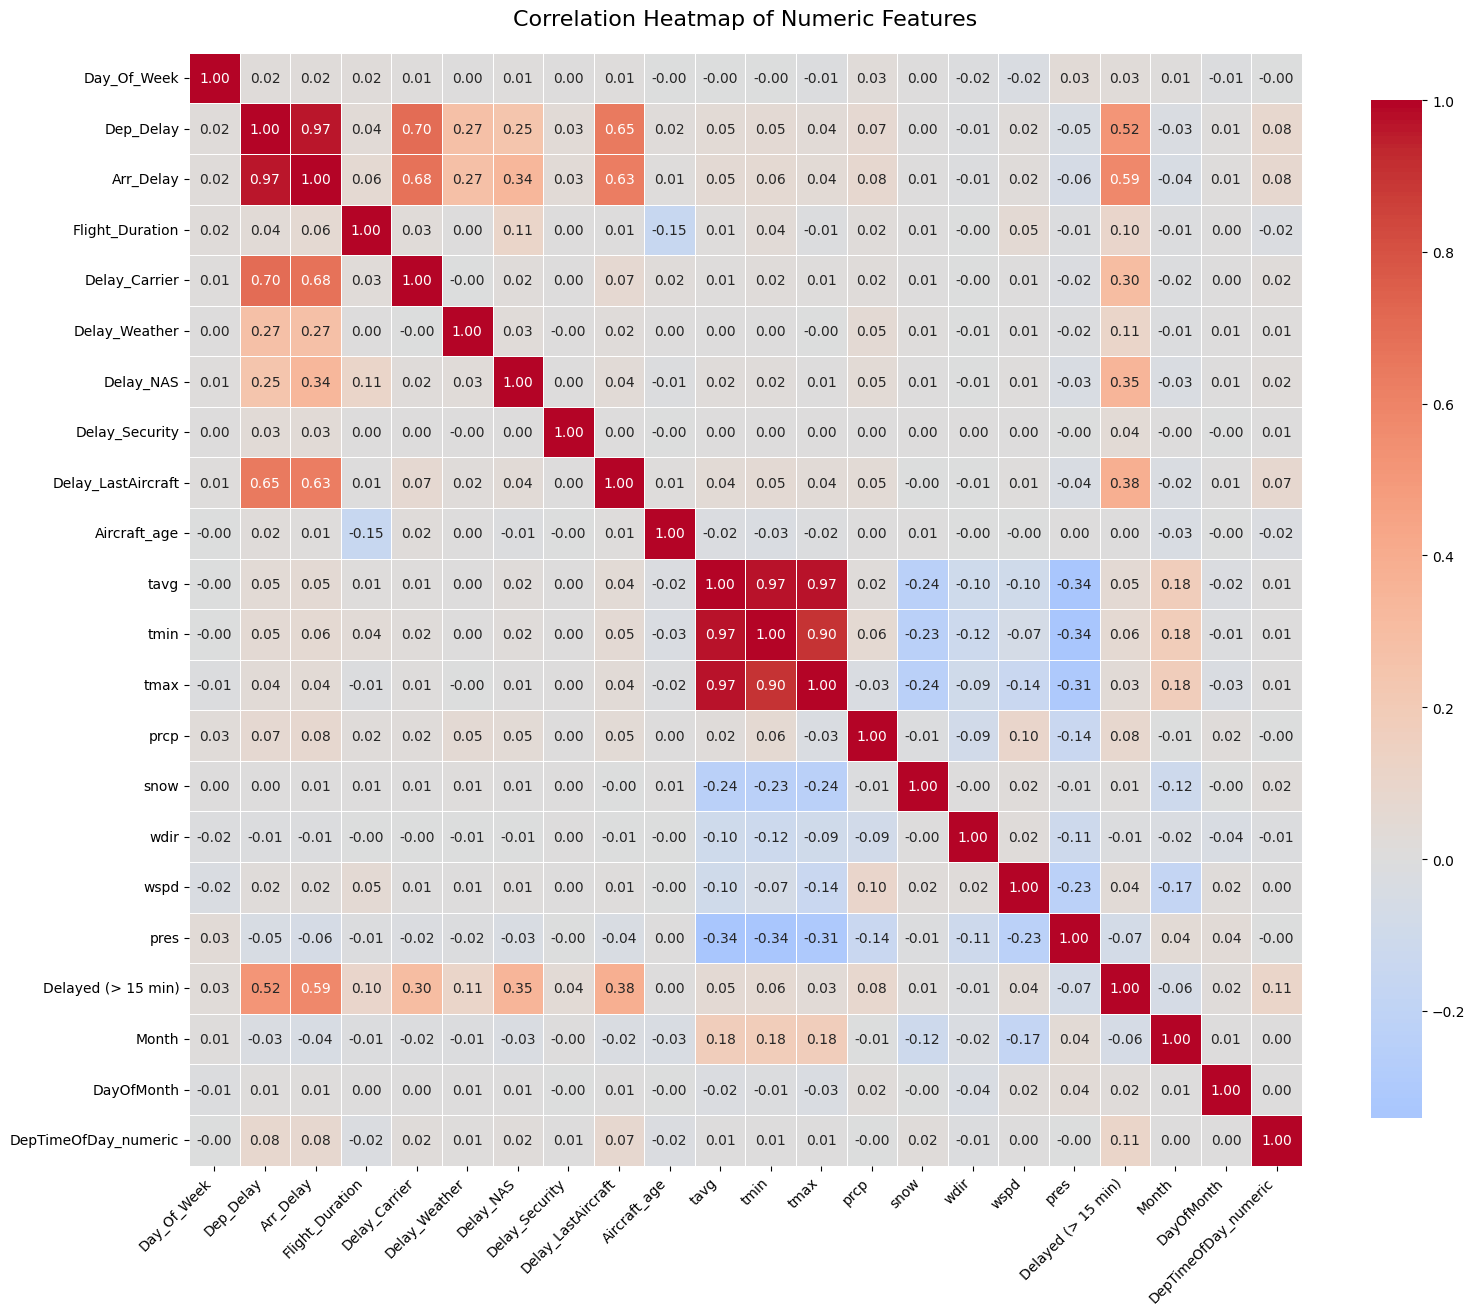


✅ Correlation heatmap complete!


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql.types import NumericType

# Select only numeric columns for correlation
numeric_cols = [field.name for field in cleaned_df.schema.fields 
                if isinstance(field.dataType, NumericType)]

print(f"Computing correlations for {len(numeric_cols)} numeric features...")
print(f"Features: {numeric_cols}")

# Sample data and convert to pandas for correlation computation
# Using a sample for performance - adjust sample size as needed
corr_data = cleaned_df.select(numeric_cols).sample(fraction=0.1, seed=42).toPandas()

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Create heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Numeric Features', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print("\n✅ Correlation heatmap complete!")

In [0]:
# Remove highly correlated and redundant/unnecessary features
cols_to_remove = ["tmin", "tmax", "Tail_Number", "Manufacturer"]

print(f"Removing {len(cols_to_remove)} features:")
for col in cols_to_remove:
    print(f"  - {col}")

# Create ML-ready dataframe
cleaned_df = cleaned_df.drop(*cols_to_remove)

# Display sample
display(cleaned_df.limit(5))

Removing 4 features:
  - tmin
  - tmax
  - Tail_Number
  - Manufacturer


Day_Of_Week,Airline,Dep_Airport,Dep_Delay,Arr_Airport,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Model,Aircraft_age,tavg,prcp,snow,wdir,wspd,pres,Delayed (> 15 min),Month,DayOfMonth,DepTimeOfDay_numeric
1,United Air Lines Inc.,PHL,-7,ORD,-28,124,0,0,0,0,0,737 NG,13.0,9.1,0.0,0.0,267.0,13.7,1010.4,0,12,4,2
1,United Air Lines Inc.,CLE,-5,EWR,-13,85,0,0,0,0,0,737 NG,26.0,4.6,0.5,0.0,256.0,14.4,1014.2,0,12,4,0
1,United Air Lines Inc.,ORD,0,SYR,-11,100,0,0,0,0,0,A319,27.0,2.8,0.0,0.0,283.0,9.7,1015.1,0,12,4,2
1,United Air Lines Inc.,ATL,-7,DEN,-2,214,0,0,0,0,0,A319,26.0,11.4,0.0,0.0,292.0,9.7,1014.5,0,12,4,0
7,United Air Lines Inc.,ORD,-5,LGA,4,139,0,0,0,0,0,A319,26.0,4.1,7.1,0.0,274.0,11.5,1008.2,0,12,3,0


In [0]:
from pyspark.sql.types import StringType

# Check what categorical features we have
categorical_cols = [field.name for field in cleaned_df.schema.fields 
                   if isinstance(field.dataType, StringType)]

print(f"Current categorical features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")

Current categorical features (4):
  - Airline
  - Dep_Airport
  - Arr_Airport
  - Model


In [0]:
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml import Pipeline

# Get current categorical columns
categorical_cols = [field.name for field in cleaned_df.schema.fields 
                   if isinstance(field.dataType, StringType)]

print(f"Encoding {len(categorical_cols)} categorical features...\n")

# Create StringIndexer stages (convert strings to numeric indices)
indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_indexed", handleInvalid="keep")
    for col in categorical_cols
]

# Create OneHotEncoder stages (convert indices to binary vectors)
encoders = [
    OneHotEncoder(inputCol=col + "_indexed", outputCol=col + "_encoded")
    for col in categorical_cols
]

# Combine all stages into a pipeline
pipeline = Pipeline(stages=indexers + encoders)

# Fit and transform the data
print("Fitting encoding pipeline...")
encoding_model = pipeline.fit(cleaned_df)
print("Transforming data...")
cleaned_df = encoding_model.transform(cleaned_df)

# Drop original categorical columns and indexed columns (keep only encoded)
columns_to_drop = categorical_cols + [col + "_indexed" for col in categorical_cols]
cleaned_df = cleaned_df.drop(*columns_to_drop)

print(f"\n✅ Encoding complete!")
print(f"Final number of columns: {len(cleaned_df.columns)}")
print(f"\nNew encoded columns added:")
for col in categorical_cols:
    print(f"  - {col}_encoded")

# Display sample
display(cleaned_df.limit(3))

Encoding 4 categorical features...

Fitting encoding pipeline...
Transforming data...

✅ Encoding complete!
Final number of columns: 24

New encoded columns added:
  - Airline_encoded
  - Dep_Airport_encoded
  - Arr_Airport_encoded
  - Model_encoded


Day_Of_Week,Dep_Delay,Arr_Delay,Flight_Duration,Delay_Carrier,Delay_Weather,Delay_NAS,Delay_Security,Delay_LastAircraft,Aircraft_age,tavg,prcp,snow,wdir,wspd,pres,Delayed (> 15 min),Month,DayOfMonth,DepTimeOfDay_numeric,Airline_encoded,Dep_Airport_encoded,Arr_Airport_encoded,Model_encoded
1,-7,-28,124,0,0,0,0,0,13.0,9.1,0.0,0.0,267.0,13.7,1010.4,0,12,4,2,"{""type"":""0"",""size"":""15"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""25""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""21"",""indices"":[""0""],""values"":[""1.0""]}"
1,-5,-13,85,0,0,0,0,0,26.0,4.6,0.5,0.0,256.0,14.4,1014.2,0,12,4,0,"{""type"":""0"",""size"":""15"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""44""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""13""],""values"":[""1.0""]}","{""type"":""0"",""size"":""21"",""indices"":[""0""],""values"":[""1.0""]}"
1,0,-11,100,0,0,0,0,0,27.0,2.8,0.0,0.0,283.0,9.7,1015.1,0,12,4,2,"{""type"":""0"",""size"":""15"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""3""],""values"":[""1.0""]}","{""type"":""0"",""size"":""350"",""indices"":[""86""],""values"":[""1.0""]}","{""type"":""0"",""size"":""21"",""indices"":[""5""],""values"":[""1.0""]}"


In [0]:
# Create 80/20 train/test split on the full dataframe
# This split will be used for both classification and regression tasks

# Set seed for reproducibility
seed = 42

# Split the data
train_df, test_df = cleaned_df.randomSplit([0.8, 0.2], seed=seed)

# Display split sizes
train_count = train_df.count()
test_count = test_df.count()
total_count = train_count + test_count

print(f"Total rows: {total_count:,}")
print(f"Train set: {train_count:,} ({train_count/total_count*100:.1f}%)")
print(f"Test set: {test_count:,} ({test_count/total_count*100:.1f}%)")

Total rows: 6,742,823
Train set: 5,394,420 (80.0%)
Test set: 1,348,403 (20.0%)


In [0]:
train_df.printSchema()

root
 |-- Day_Of_Week: long (nullable = true)
 |-- Dep_Delay: long (nullable = true)
 |-- Arr_Delay: long (nullable = true)
 |-- Flight_Duration: long (nullable = true)
 |-- Delay_Carrier: long (nullable = true)
 |-- Delay_Weather: long (nullable = true)
 |-- Delay_NAS: long (nullable = true)
 |-- Delay_Security: long (nullable = true)
 |-- Delay_LastAircraft: long (nullable = true)
 |-- Aircraft_age: double (nullable = true)
 |-- tavg: double (nullable = true)
 |-- prcp: double (nullable = true)
 |-- snow: double (nullable = true)
 |-- wdir: double (nullable = true)
 |-- wspd: double (nullable = true)
 |-- pres: double (nullable = true)
 |-- Delayed (> 15 min): integer (nullable = false)
 |-- Month: integer (nullable = true)
 |-- DayOfMonth: integer (nullable = true)
 |-- DepTimeOfDay_numeric: integer (nullable = true)
 |-- Airline_encoded: vectorudt (nullable = true)
 |-- Dep_Airport_encoded: vectorudt (nullable = true)
 |-- Arr_Airport_encoded: vectorudt (nullable = true)
 |-- Model

# Regression

In [0]:
from pyspark.sql.types import StringType, NumericType
from pyspark.sql.functions import col

# Define target column for regression
target_col = "Arr_Delay"

print(f"=== Regression Feature Sets (Delayed Flights Only) ===")
print(f"Target: {target_col}")

# Filter for delayed flights only (Delayed >= 15 min)
train_delayed = train_df.filter(col("Delayed (> 15 min)") == 1)
test_delayed = test_df.filter(col("Delayed (> 15 min)") == 1)

print(f"\nFiltered to delayed flights only:")
print(f"  Train: {train_delayed.count():,} delayed flights (from {train_df.count():,} total)")
print(f"  Test: {test_delayed.count():,} delayed flights (from {test_df.count():,} total)")

# Columns to exclude from features
exclude_cols = [
    target_col,  # Regression target
    "Delayed (> 15 min)"  # Classification target (not needed for regression)
]

# Get all feature columns (everything except targets)
feature_cols = [col for col in train_delayed.columns if col not in exclude_cols]

print(f"\nTotal features: {len(feature_cols)}")

# Create X and y for train set
X_train_reg = train_delayed.select(feature_cols)
y_train_reg = train_delayed.select(target_col)

# Create X and y for test set
X_test_reg = test_delayed.select(feature_cols)
y_test_reg = test_delayed.select(target_col)

print(f"\n=== Train Set ===")
print(f"X_train_reg shape: ({X_train_reg.count()}, {len(X_train_reg.columns)})")
print(f"y_train_reg shape: ({y_train_reg.count()}, 1)")

print(f"\n=== Test Set ===")
print(f"X_test_reg shape: ({X_test_reg.count()}, {len(X_test_reg.columns)})")
print(f"y_test_reg shape: ({y_test_reg.count()}, 1)")

=== Regression Feature Sets (Delayed Flights Only) ===
Target: Arr_Delay

Filtered to delayed flights only:
  Train: 1,071,316 delayed flights (from 5,394,420 total)
  Test: 267,812 delayed flights (from 1,348,451 total)

Total features: 22

=== Train Set ===
X_train_reg shape: (1071316, 22)
y_train_reg shape: (1071316, 1)

=== Test Set ===
X_test_reg shape: (267812, 22)
y_test_reg shape: (267812, 1)


In [0]:
from pyspark.ml.feature import VectorAssembler
print("=== Preparing Features for Decision Tree Regression ===")

# Get feature column names (all columns except targets)
feature_cols = [col for col in train_delayed.columns if col not in ["Arr_Delay", "Delayed (> 15 min)"]]

print(f"Number of features: {len(feature_cols)}")
print(f"\nAssembling feature vector...")

# Create VectorAssembler to combine all features into a single vector column
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")

# Transform train and test data using FILTERED datasets (delayed flights only)
train_data = assembler.transform(train_delayed.withColumnRenamed("Arr_Delay", "label"))
test_data = assembler.transform(test_delayed.withColumnRenamed("Arr_Delay", "label"))

=== Preparing Features for Decision Tree Regression ===
Number of features: 22

Assembling feature vector...


In [0]:
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import time


print(f"\n=== Training Decision Tree Regressor ===")
start_time = time.time()

# Initialize Decision Tree Regressor
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,  # Control overfitting
    maxBins=32,   # Number of bins for continuous features
    seed=42
)

# Train the model
dt_model = dt.fit(train_data)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Tree depth: {dt_model.depth}")
print(f"  - Number of nodes: {dt_model.numNodes}")
print(f"  - Feature importance available: {len(dt_model.featureImportances) > 0}")


=== Training Decision Tree Regressor ===
✅ Training complete in 43.28 seconds

Model details:
  - Tree depth: 10
  - Number of nodes: 1641
  - Feature importance available: True


In [0]:
# Initialize evaluators for different metrics
from pyspark.ml.evaluation import RegressionEvaluator
rmse_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
mae_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
r2_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

In [0]:
print("=== Making Predictions ===")

# Make predictions on train and test sets
train_predictions = dt_model.transform(train_data)
test_predictions = dt_model.transform(test_data)

print(f"✅ Predictions complete")

print("\n=== Model Evaluation ===")

# Evaluate on training set
train_rmse = rmse_evaluator.evaluate(train_predictions)
train_mae = mae_evaluator.evaluate(train_predictions)
train_r2 = r2_evaluator.evaluate(train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {train_rmse:.2f} minutes")
print(f"  MAE:  {train_mae:.2f} minutes")
print(f"  R²:   {train_r2:.4f}")

# Evaluate on test set
test_rmse = rmse_evaluator.evaluate(test_predictions)
test_mae = mae_evaluator.evaluate(test_predictions)
test_r2 = r2_evaluator.evaluate(test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {test_rmse:.2f} minutes")
print(f"  MAE:  {test_mae:.2f} minutes")
print(f"  R²:   {test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {train_rmse - test_rmse:.2f}")
print(f"  R² difference (train - test): {train_r2 - test_r2:.4f}")

if train_rmse < test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(test_predictions.select("label", "prediction").limit(10))

=== Making Predictions ===
✅ Predictions complete

=== Model Evaluation ===

Training Set Performance:
  RMSE: 39.51 minutes
  MAE:  10.63 minutes
  R²:   0.8340

Test Set Performance:
  RMSE: 41.98 minutes
  MAE:  10.91 minutes
  R²:   0.8110

Overfitting Check:
  RMSE difference (train - test): -2.47
  R² difference (train - test): 0.0230
  ✅ Model generalizes well

=== Sample Predictions ===


label,prediction
19,22.168057710858534
24,25.671687398593836
30,32.39149703297529
17,22.168057710858534
19,22.168057710858534
20,22.168057710858534
18,22.168057710858534
22,25.671687398593836
27,25.671687398593836
21,22.168057710858534


In [0]:
from pyspark.ml.regression import RandomForestRegressor
import time

print("=== Training Random Forest Regressor ===")
start_time = time.time()

# Initialize Random Forest Regressor
# Reduced complexity to avoid OOM errors on serverless compute
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=30,       # Reduced from 100 to avoid memory issues
    maxDepth=10,        
    maxBins=32,        # Number of bins for continuous features
    seed=42
)

# Train the model (reuse train_data from previous cell)
rf_model = rf.fit(train_data)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Number of trees: {rf_model.getNumTrees}")
print(f"  - Max tree depth: {rf_model.getMaxDepth}")
print(f"  - Feature importance available: {len(rf_model.featureImportances) > 0}")

=== Training Random Forest Regressor ===
✅ Training complete in 236.61 seconds

Model details:
  - Number of trees: 30
  - Max tree depth: <bound method _DecisionTreeParams.getMaxDepth of RandomForestRegressionModel: uid=RandomForestRegressor_2e8f50a193b6, numTrees=30, numFeatures=754>
  - Feature importance available: True


In [0]:
print("=== Making Predictions with Random Forest ===")

# Make predictions on train and test sets
rf_train_predictions = rf_model.transform(train_data)
rf_test_predictions = rf_model.transform(test_data)

print(f"✅ Predictions complete")

print("\n=== Random Forest Model Evaluation ===")

# Evaluate on training set
rf_train_rmse = rmse_evaluator.evaluate(rf_train_predictions)
rf_train_mae = mae_evaluator.evaluate(rf_train_predictions)
rf_train_r2 = r2_evaluator.evaluate(rf_train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {rf_train_rmse:.2f} minutes")
print(f"  MAE:  {rf_train_mae:.2f} minutes")
print(f"  R²:   {rf_train_r2:.4f}")

# Evaluate on test set
rf_test_rmse = rmse_evaluator.evaluate(rf_test_predictions)
rf_test_mae = mae_evaluator.evaluate(rf_test_predictions)
rf_test_r2 = r2_evaluator.evaluate(rf_test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {rf_test_rmse:.2f} minutes")
print(f"  MAE:  {rf_test_mae:.2f} minutes")
print(f"  R²:   {rf_test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {rf_train_rmse - rf_test_rmse:.2f}")
print(f"  R² difference (train - test): {rf_train_r2 - rf_test_r2:.4f}")

if rf_train_rmse < rf_test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Compare with Decision Tree
print(f"\n=== Comparison: Random Forest vs Decision Tree ===")
print(f"\nTest Set RMSE:")
print(f"  Decision Tree: {test_rmse:.2f} minutes")
print(f"  Random Forest: {rf_test_rmse:.2f} minutes")
print(f"  Improvement: {test_rmse - rf_test_rmse:.2f} minutes ({((test_rmse - rf_test_rmse)/test_rmse*100):.1f}%)")

print(f"\nTest Set R²:")
print(f"  Decision Tree: {test_r2:.4f}")
print(f"  Random Forest: {rf_test_r2:.4f}")
print(f"  Improvement: {rf_test_r2 - test_r2:.4f}")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(rf_test_predictions.select("label", "prediction").limit(10))

=== Making Predictions with Random Forest ===
✅ Predictions complete

=== Random Forest Model Evaluation ===

Training Set Performance:
  RMSE: 39.71 minutes
  MAE:  11.90 minutes
  R²:   0.8324

Test Set Performance:
  RMSE: 41.19 minutes
  MAE:  12.07 minutes
  R²:   0.8181

Overfitting Check:
  RMSE difference (train - test): -1.48
  R² difference (train - test): 0.0143
  ✅ Model generalizes well

=== Comparison: Random Forest vs Decision Tree ===

Test Set RMSE:
  Decision Tree: 41.98 minutes
  Random Forest: 41.19 minutes
  Improvement: 0.79 minutes (1.9%)

Test Set R²:
  Decision Tree: 0.8110
  Random Forest: 0.8181
  Improvement: 0.0071

=== Sample Predictions ===


label,prediction
19,27.2842966469391
24,26.527568258699926
30,31.923924367485807
17,26.099529104435103
19,26.943334840711433
20,26.52109041040329
18,26.48539853870469
22,27.745229135479573
27,29.542675480533674
21,26.96191280441221


In [0]:
# XGBoost not available for serverless compute, so using similar model
from pyspark.ml.regression import GBTRegressor
import time

print("=== Training Gradient-Boosted Trees Regressor ===")
print("Note: Using Spark ML's GBTRegressor (similar to XGBoost)\n")
start_time = time.time()

# Initialize Gradient-Boosted Trees Regressor
# Spark ML's native gradient boosting implementation
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,           # Depth of trees
    maxIter=50,           # Number of boosting iterations
    stepSize=0.1,         # Learning rate / step size shrinkage
    subsamplingRate=0.8,  # Subsample ratio of training instances
    maxBins=32,
    seed=42
)

# Train the model (reuse train_data from previous cells)
gbt_model = gbt.fit(train_data)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Number of trees: {gbt_model.getNumTrees}")
print(f"  - Max tree depth: {gbt.getMaxDepth}")
print(f"  - Learning rate (step size): {gbt.getStepSize}")
print(f"  - Feature importance available: {len(gbt_model.featureImportances) > 0}")

=== Training Gradient-Boosted Trees Regressor ===
Note: Using Spark ML's GBTRegressor (similar to XGBoost)

✅ Training complete in 805.96 seconds

Model details:
  - Number of trees: 50
  - Max tree depth: <bound method _DecisionTreeParams.getMaxDepth of GBTRegressor_d47815f56c35>
  - Learning rate (step size): <bound method HasStepSize.getStepSize of GBTRegressor_d47815f56c35>
  - Feature importance available: True


In [0]:
print("=== Making Predictions with Gradient-Boosted Trees ===")

# Make predictions on train and test sets
gbt_train_predictions = gbt_model.transform(train_data)
gbt_test_predictions = gbt_model.transform(test_data)

print(f"✅ Predictions complete")

print("\n=== Gradient-Boosted Trees Model Evaluation ===")

# Evaluate on training set
gbt_train_rmse = rmse_evaluator.evaluate(gbt_train_predictions)
gbt_train_mae = mae_evaluator.evaluate(gbt_train_predictions)
gbt_train_r2 = r2_evaluator.evaluate(gbt_train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {gbt_train_rmse:.2f} minutes")
print(f"  MAE:  {gbt_train_mae:.2f} minutes")
print(f"  R²:   {gbt_train_r2:.4f}")

# Evaluate on test set
gbt_test_rmse = rmse_evaluator.evaluate(gbt_test_predictions)
gbt_test_mae = mae_evaluator.evaluate(gbt_test_predictions)
gbt_test_r2 = r2_evaluator.evaluate(gbt_test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {gbt_test_rmse:.2f} minutes")
print(f"  MAE:  {gbt_test_mae:.2f} minutes")
print(f"  R²:   {gbt_test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {gbt_train_rmse - gbt_test_rmse:.2f}")
print(f"  R² difference (train - test): {gbt_train_r2 - gbt_test_r2:.4f}")

if gbt_train_rmse < gbt_test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Compare all three models
print(f"\n=== Model Comparison Summary ===")
print(f"\n{'Model':<20} {'Test RMSE':<15} {'Test MAE':<15} {'Test R²':<10}")
print("=" * 65)
print(f"{'Decision Tree':<20} {test_rmse:<15.2f} {test_mae:<15.2f} {test_r2:<10.4f}")
print(f"{'Random Forest':<20} {rf_test_rmse:<15.2f} {rf_test_mae:<15.2f} {rf_test_r2:<10.4f}")
print(f"{'Gradient Boosting':<20} {gbt_test_rmse:<15.2f} {gbt_test_mae:<15.2f} {gbt_test_r2:<10.4f}")

# Find best model
best_rmse = min(test_rmse, rf_test_rmse, gbt_test_rmse)
best_r2 = max(test_r2, rf_test_r2, gbt_test_r2)

if gbt_test_rmse == best_rmse and gbt_test_r2 == best_r2:
    print(f"\n⭐ Best Model: Gradient Boosting (lowest RMSE and highest R²)")
elif test_rmse == best_rmse and test_r2 == best_r2:
    print(f"\n⭐ Best Model: Decision Tree (lowest RMSE and highest R²)")
elif rf_test_rmse == best_rmse and rf_test_r2 == best_r2:
    print(f"\n⭐ Best Model: Random Forest (lowest RMSE and highest R²)")
else:
    print(f"\n⭐ Best RMSE: {best_rmse:.2f} minutes")
    print(f"\n⭐ Best R²: {best_r2:.4f}")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(gbt_test_predictions.select("label", "prediction").limit(10))

=== Making Predictions with Gradient-Boosted Trees ===
✅ Predictions complete

=== Gradient-Boosted Trees Model Evaluation ===

Training Set Performance:
  RMSE: 34.03 minutes
  MAE:  7.70 minutes
  R²:   0.8769

Test Set Performance:
  RMSE: 41.38 minutes
  MAE:  8.59 minutes
  R²:   0.8164

Overfitting Check:
  RMSE difference (train - test): -7.35
  R² difference (train - test): 0.0605
  ✅ Model generalizes well

=== Model Comparison Summary ===

Model                Test RMSE       Test MAE        Test R²   
Decision Tree        41.98           10.91           0.8110    
Random Forest        41.19           12.07           0.8181    
Gradient Boosting    41.38           8.59            0.8164    

⭐ Best Model: Random Forest (lowest RMSE and highest R²)

=== Sample Predictions ===


label,prediction
19,19.130240359666242
24,23.49118340937703
30,32.126127121089176
17,16.723674054910198
19,18.984789239247235
20,20.108698183336365
18,18.270297633643523
22,22.311817850912753
27,27.266096161077506
21,20.51169019796576


=== Feature Importance Analysis (Original GBT - WITH Leakage) ===

Debug info:
  Number of features: 22
  Number of importances: 754

⚠️ Length mismatch detected!
  Truncating to 22 features

All 22 Features (sorted by importance):
Dep_Delay                                0.553791
Delay_NAS                                0.028552
DepTimeOfDay_numeric                     0.027325
Delay_LastAircraft                       0.023712
Flight_Duration                          0.021969
Delay_Carrier                            0.021246
Day_Of_Week                              0.017486
tavg                                     0.017160
DayOfMonth                               0.016299
Aircraft_age                             0.016263
wdir                                     0.014572
wspd                                     0.013920
pres                                     0.013780
Month                                    0.009544
prcp                                     0.009076
Delay_Weather     

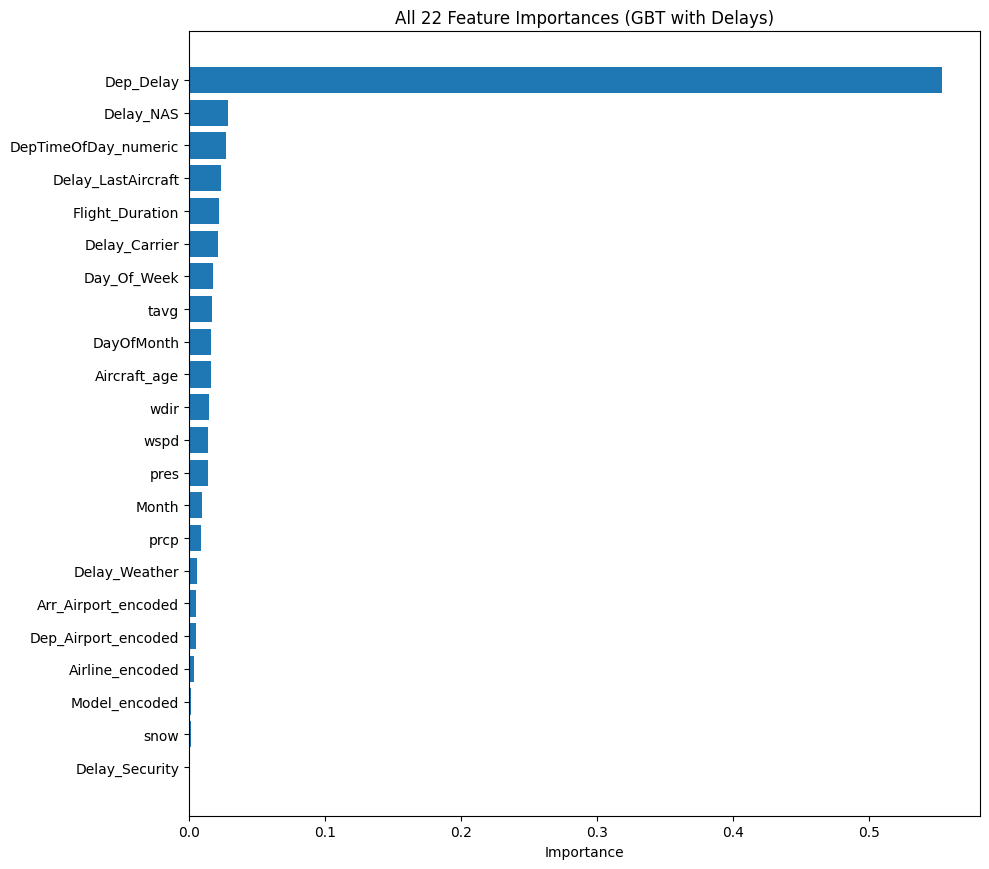


✅ Total features: 22
✅ Non-zero importances: 22
✅ Zero importances: 0

 Features with Delays Importance:
  Delay_NAS                      0.028552
  Delay_LastAircraft             0.023712
  Delay_Carrier                  0.021246
  Delay_Weather                  0.005614
  Delay_Security                 0.000667
  Total leakage impact: 0.0798 (8.0%)


In [0]:
import pandas as pd
import matplotlib.pyplot as plt

print("=== Feature Importance Analysis (Original GBT - WITH Leakage) ===")

# Get feature importances from the model
importances = gbt_model.featureImportances.toArray()

# Get feature names from the original assembler (includes delay features)
feature_names = assembler.getInputCols()

print(f"\nDebug info:")
print(f"  Number of features: {len(feature_names)}")
print(f"  Number of importances: {len(importances)}")

# Ensure lengths match
if len(feature_names) != len(importances):
    print(f"\n⚠️ Length mismatch detected!")
    min_len = min(len(feature_names), len(importances))
    feature_names = feature_names[:min_len]
    importances = importances[:min_len]
    print(f"  Truncating to {min_len} features")

# Create DataFrame for easier visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display all features
print(f"\nAll {len(feature_importance_df)} Features (sorted by importance):")
print("=" * 60)
for idx, row in feature_importance_df.iterrows():
    print(f"{row['Feature']:<40} {row['Importance']:.6f}")

# Visualize all features
plt.figure(figsize=(10, max(8, len(feature_importance_df) * 0.4)))
plt.barh(range(len(feature_importance_df)), feature_importance_df['Importance'])
plt.yticks(range(len(feature_importance_df)), feature_importance_df['Feature'])
plt.xlabel('Importance')
plt.title(f'All {len(feature_importance_df)} Feature Importances (GBT with Delays)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✅ Total features: {len(feature_names)}")
print(f"✅ Non-zero importances: {(importances > 0).sum()}")
print(f"✅ Zero importances: {(importances == 0).sum()}")

# Highlight the leakage features
leakage_cols = ['Delay_Carrier', 'Delay_Weather', 'Delay_NAS', 'Delay_Security', 'Delay_LastAircraft']
leakage_importance = feature_importance_df[feature_importance_df['Feature'].isin(leakage_cols)]
if not leakage_importance.empty:
    print(f"\n Features with Delays Importance:")
    for idx, row in leakage_importance.iterrows():
        print(f"  {row['Feature']:<30} {row['Importance']:.6f}")
    print(f"  Total leakage impact: {leakage_importance['Importance'].sum():.4f} ({leakage_importance['Importance'].sum()*100:.1f}%)")

In [0]:
from pyspark.ml.feature import StandardScaler

print("=== Preparing Features for Linear Regression ===")
print("Note: Linear regression requires feature scaling\n")

# The feature vector is already assembled in train_data and test_data
# Now we need to scale the features

print("Fitting StandardScaler on training data...")
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,   # Center the data (mean = 0)
    withStd=True     # Scale to unit variance (std = 1)
)

# Fit the scaler on training data
scaler_model = scaler.fit(train_data)

# Transform both train and test data
print("Scaling features...")
train_data_scaled = scaler_model.transform(train_data)
test_data_scaled = scaler_model.transform(test_data)

print(f"\n✅ Feature scaling complete!")
print(f"\nScaled feature column: 'scaled_features'")
print(f"Train data: {train_data_scaled.count():,} rows")
print(f"Test data: {test_data_scaled.count():,} rows")

# Display sample to show both original and scaled features
print("\n=== Sample (showing original and scaled features) ===")
display(train_data_scaled.select("label", "features", "scaled_features").limit(3))

=== Preparing Features for Linear Regression ===
Note: Linear regression requires feature scaling

Fitting StandardScaler on training data...
Scaling features...

✅ Feature scaling complete!

Scaled feature column: 'scaled_features'
Train data: 1,071,316 rows
Test data: 266,700 rows

=== Sample (showing original and scaled features) ===


label features scaled_features 19 {"type":"0","size":"754","indices":["0","1","2","3","8","9","10","12","13","14","15","16","17","22","288","384","737"],"values":["1.0","-25.0","127.0","19.0","21.0","16.0","10.4","27.0","14.5","1022.0","9.0","11.0","1.0","1.0","1.0","1.0","1.0"]} {"type":"1","size":null,"indices":null,"values":["-1.5406050924342023","-0.9165356920034657","-0.35488325053712316","-0.08748935306918361","-0.11842414925982504","-0.4035307019264841","-0.046690666254211956","-0.46077679505985153","0.9403322904527621","-0.17661543206271774","0.6106199861801475","-0.11993998252976229","-1.4687911875862203","0.28048543861487824","1.1827784138662392","0.8642792092927875","-0.5762895402991238","-0.112900609577168","-0.5342086938784834","-0.36025780159110593","-0.427796337952734","-0.34646432020069146","3.4415061364121025","-0.166600061438369","-0.2547878601242844","-0.24075587069932242","-0.18751240288551138","-0.1736379594148835","-0.14255975361071202","-0.1531283046760109","-0.20323763140571127","-0.14801599588986622","-0.11676935469530934","-0.2211611107328935","-0.2357571849334428","-0.22626318145255142","-0.20590962801899912","-0.18139823064048138","-0.16335228351515768","-0.19438137992700177","-0.15519397059679724","-0.15163720016647123","-0.18661707920888176","-0.1474519412703553","-0.15212928851672536","-0.13431275935748743","-0.1509367677281291","-0.14216730830038413","-0.14974537654263637","-0.12385586584009228","-0.11779585375735735","-0.13564988051490812","-0.11566382134615708","-0.14307014959437764","-0.11786914235399602","-0.13301040552341353","-0.11751451390674478","-0.11343059627601947","-0.1165021338901338","-0.14304976592390017","-0.12284193974344737","-0.10682284175020279","-0.1058667855319461","-0.09522404467784748","-0.0912982192887374","-0.09142806906448252","-0.08143613667862709","-0.08640503828455946","-0.079348464042478","-0.07725473259191419","-0.08046649834843245","-0.08465538839570598","-0.08065429995324898","-0.08004828082615406","-0.07372800045813797","-0.07718133560867539","-0.0685178108698342","-0.07333019760576986","-0.06864146393253186","-0.06926328312955969","-0.07136810008934144","-0.06742984767798425","-0.0795982388058789","-0.06650868836515662","-0.06065531835620981","-0.06398371986018013","-0.06822152721668441","-0.05706229747855944","-0.05659943004170246","-0.054390868859789464","-0.055332296404989025","-0.05181894650961393","-0.053634723937411415","-0.05114452770458129","-0.05659113058885533","-0.05110782178306202","-0.047403992006898044","-0.05291225956990128","-0.05330112712497584","-0.0527790435937947","-0.050461191309424655","-0.04720578568470322","-0.045434941280585166","-0.04798397339021204","-0.044612706501079104","-0.04179346672729447","-0.041534929364861216","-0.045103675681562705","-0.04425416929618108","-0.04049595166846162","-0.046171670912040275","-0.043721609979127635","-0.0470067510867864","-0.04447595734321402","-0.04071505635710037","-0.04371089312107129","-0.040472819470945894","-0.039901919208848086","-0.03619923302220628","-0.04116116775952872","-0.040077542742737025","-0.04378585646442377","-0.03891590357816898","-0.037966098042446925","-0.03789205578449446","-0.0393584853291047","-0.0393584853291047","-0.03639262074779108","-0.04144462790208565","-0.03340298776178238","-0.03713096093057649","-0.03432845756323889","-0.03733208515868118","-0.04049595166846162","-0.03426025191704127","-0.031142263488020527","-0.02949202752710384","-0.03045909479707756","-0.027439232142491332","-0.03250885474696248","-0.031142263488020527","-0.030520437794452515","-0.027010018330117597","-0.03150058548375704","-0.02446808502680861","-0.028574190989933638","-0.030320620980446612","-0.027061882362570747","-0.029681652134874285","-0.031928214080616295","-0.029932622881355973","-0.029317131311902965","-0.027524274116346146","-0.027216883211523508","-0.035991813516343125","-0.02510901917956032","-0.031884241537613635","-0.02396642470170138","-0.025679496252292083","-0.02730261568584668

In [0]:
from pyspark.ml.regression import LinearRegression
import time

print("=== Training Linear Regression Model ===")
start_time = time.time()

# Initialize Linear Regression
lr = LinearRegression(
    featuresCol="scaled_features",  # Use scaled features
    labelCol="label",
    maxIter=100,           # Maximum iterations
    regParam=0.1,          # L2 regularization parameter
    elasticNetParam=0.0,   # 0 = L2 (Ridge), 1 = L1 (Lasso), between = Elastic Net
    standardization=False  # We already scaled manually
)

# Train the model
lr_model = lr.fit(train_data_scaled)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Intercept: {lr_model.intercept:.2f}")
print(f"  - Number of features: {len(lr_model.coefficients)}")
print(f"  - Regularization: L2 (Ridge) with lambda={lr.getRegParam()}")

# Training summary
training_summary = lr_model.summary
print(f"\nTraining Summary:")
print(f"  - Total iterations: {training_summary.totalIterations}")
print(f"  - Objective history length: {len(training_summary.objectiveHistory)}")
print(f"  - RMSE: {training_summary.rootMeanSquaredError:.2f}")
print(f"  - R²: {training_summary.r2:.4f}")

=== Training Linear Regression Model ===
✅ Training complete in 55.55 seconds

Model details:
  - Intercept: 70.23
  - Number of features: 754
  - Regularization: L2 (Ridge) with lambda=0.1

Training Summary:
  - Total iterations: 39
  - Objective history length: 40
  - RMSE: 0.67
  - R²: 1.0000


In [0]:
print("=== Making Predictions with Linear Regression ===")

# Make predictions on train and test sets
lr_train_predictions = lr_model.transform(train_data_scaled)
lr_test_predictions = lr_model.transform(test_data_scaled)

print(f"✅ Predictions complete")

print("\n=== Linear Regression Model Evaluation ===")

# Evaluate on training set
lr_train_rmse = rmse_evaluator.evaluate(lr_train_predictions)
lr_train_mae = mae_evaluator.evaluate(lr_train_predictions)
lr_train_r2 = r2_evaluator.evaluate(lr_train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {lr_train_rmse:.2f} minutes")
print(f"  MAE:  {lr_train_mae:.2f} minutes")
print(f"  R²:   {lr_train_r2:.4f}")

# Evaluate on test set
lr_test_rmse = rmse_evaluator.evaluate(lr_test_predictions)
lr_test_mae = mae_evaluator.evaluate(lr_test_predictions)
lr_test_r2 = r2_evaluator.evaluate(lr_test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {lr_test_rmse:.2f} minutes")
print(f"  MAE:  {lr_test_mae:.2f} minutes")
print(f"  R²:   {lr_test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {lr_train_rmse - lr_test_rmse:.2f}")
print(f"  R² difference (train - test): {lr_train_r2 - lr_test_r2:.4f}")

if lr_train_rmse < lr_test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Compare all four models
print(f"\n=== Model Comparison Summary ===")
print(f"\n{'Model':<20} {'Test RMSE':<15} {'Test MAE':<15} {'Test R²':<10}")
print("=" * 65)
print(f"{'Decision Tree':<20} {test_rmse:<15.2f} {test_mae:<15.2f} {test_r2:<10.4f}")
print(f"{'Random Forest':<20} {rf_test_rmse:<15.2f} {rf_test_mae:<15.2f} {rf_test_r2:<10.4f}")
print(f"{'Gradient Boosting':<20} {gbt_test_rmse:<15.2f} {gbt_test_mae:<15.2f} {gbt_test_r2:<10.4f}")
print(f"{'Linear Regression':<20} {lr_test_rmse:<15.2f} {lr_test_mae:<15.2f} {lr_test_r2:<10.4f}")

# Find best model
best_rmse = min(test_rmse, rf_test_rmse, gbt_test_rmse, lr_test_rmse)
best_r2 = max(test_r2, rf_test_r2, gbt_test_r2, lr_test_r2)

print(f"\n⭐ Best RMSE: {best_rmse:.2f} minutes")
print(f"⭐ Best R²: {best_r2:.4f}")

if lr_test_rmse == best_rmse and lr_test_r2 == best_r2:
    print(f"\n✅ Linear Regression is the best model!")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(lr_test_predictions.select("label", "prediction").limit(10))

=== Making Predictions with Linear Regression ===
✅ Predictions complete

=== Linear Regression Model Evaluation ===

Training Set Performance:
  RMSE: 0.67 minutes
  MAE:  0.45 minutes
  R²:   1.0000

Test Set Performance:
  RMSE: 0.63 minutes
  MAE:  0.45 minutes
  R²:   1.0000

Overfitting Check:
  RMSE difference (train - test): 0.04
  R² difference (train - test): -0.0000
  ✅ Model generalizes well

=== Model Comparison Summary ===

Model                Test RMSE       Test MAE        Test R²   
Decision Tree        41.98           10.91           0.8110    
Random Forest        41.19           12.07           0.8181    
Gradient Boosting    41.38           8.59            0.8164    
Linear Regression    0.63            0.45            1.0000    

⭐ Best RMSE: 0.63 minutes
⭐ Best R²: 1.0000

✅ Linear Regression is the best model!

=== Sample Predictions ===


label,prediction
25,24.599551851660223
19,18.345269917846657
19,18.6452245534539
28,27.308171914594936
16,15.276737373107238
19,18.22420261418351
27,26.22424143192042
23,22.076105803131945
26,25.29353777361662
30,29.26897215156756


In [0]:
from pyspark.ml.feature import VectorAssembler

print("=== Removing Delay Breakdown Features to Fix Data Leakage ===")

# These features provide breakdown of departure delay by cause
# They give the model nearly perfect information about the delay
leakage_features = [
    "Delay_Carrier",
    "Delay_Weather", 
    "Delay_NAS",
    "Delay_Security",
    "Delay_LastAircraft",
    "Dep_Delay"
]

print(f"\nRemoving {len(leakage_features)} leakage features:")
for feat in leakage_features:
    print(f"  - {feat}")

# Drop leakage features from delayed datasets
train_delayed_clean = train_delayed.drop(*leakage_features)
test_delayed_clean = test_delayed.drop(*leakage_features)

# Get new feature column list (excluding targets and leakage features)
feature_cols_clean = [col for col in train_delayed_clean.columns 
                      if col not in ["Arr_Delay", "Delayed (> 15 min)"]]

print(f"\nFeatures after removal: {len(feature_cols_clean)} (was {len(feature_cols_clean) + len(leakage_features)})")

# Re-assemble feature vectors without leakage features
assembler_clean = VectorAssembler(inputCols=feature_cols_clean, outputCol="features", handleInvalid="skip")

train_data_no_leak = assembler_clean.transform(train_delayed_clean.withColumnRenamed("Arr_Delay", "label"))
test_data_no_leak = assembler_clean.transform(test_delayed_clean.withColumnRenamed("Arr_Delay", "label"))

print(f"\n✅ Clean datasets created!")
print(f"\nUse these variables for models without data leakage:")
print(f"  - train_data_no_leak: {train_data_no_leak.count():,} rows")
print(f"  - test_data_no_leak: {test_data_no_leak.count():,} rows")
print(f"\nOriginal datasets (with leakage) remain in:")
print(f"  - train_data")
print(f"  - test_data")

=== Removing Delay Breakdown Features to Fix Data Leakage ===

Removing 6 leakage features:
  - Delay_Carrier
  - Delay_Weather
  - Delay_NAS
  - Delay_Security
  - Delay_LastAircraft
  - Dep_Delay

Features after removal: 16 (was 22)

✅ Clean datasets created!

Use these variables for models without data leakage:
  - train_data_no_leak: 1,071,316 rows
  - test_data_no_leak: 267,812 rows

Original datasets (with leakage) remain in:
  - train_data
  - test_data


In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator
import time

print(f"\n=== Training Decision Tree Regressor ===")
start_time = time.time()

# Initialize Decision Tree Regressor
dt = DecisionTreeRegressor(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,  # Control overfitting
    maxBins=32,   # Number of bins for continuous features
    seed=42
)

# Train the model
dt_model = dt.fit(train_data_no_leak)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Tree depth: {dt_model.depth}")
print(f"  - Number of nodes: {dt_model.numNodes}")
print(f"  - Feature importance available: {len(dt_model.featureImportances) > 0}")


=== Training Decision Tree Regressor ===
✅ Training complete in 44.54 seconds

Model details:
  - Tree depth: 10
  - Number of nodes: 1585
  - Feature importance available: True


In [0]:
print("=== Making Predictions ===")

# Make predictions on train and test sets
train_predictions = dt_model.transform(train_data_no_leak)
test_predictions = dt_model.transform(test_data_no_leak)

print(f"✅ Predictions complete")

# Initialize evaluators for different metrics
rmse_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="rmse")
mae_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="mae")
r2_evaluator = RegressionEvaluator(labelCol="label", predictionCol="prediction", metricName="r2")

print("\n=== Model Evaluation ===")

# Evaluate on training set
train_rmse = rmse_evaluator.evaluate(train_predictions)
train_mae = mae_evaluator.evaluate(train_predictions)
train_r2 = r2_evaluator.evaluate(train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {train_rmse:.2f} minutes")
print(f"  MAE:  {train_mae:.2f} minutes")
print(f"  R²:   {train_r2:.4f}")

# Evaluate on test set
test_rmse = rmse_evaluator.evaluate(test_predictions)
test_mae = mae_evaluator.evaluate(test_predictions)
test_r2 = r2_evaluator.evaluate(test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {test_rmse:.2f} minutes")
print(f"  MAE:  {test_mae:.2f} minutes")
print(f"  R²:   {test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {train_rmse - test_rmse:.2f}")
print(f"  R² difference (train - test): {train_r2 - test_r2:.4f}")

if train_rmse < test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(test_predictions.select("label", "prediction").limit(10))

=== Making Predictions ===
✅ Predictions complete

=== Model Evaluation ===

Training Set Performance:
  RMSE: 94.95 minutes
  MAE:  49.77 minutes
  R²:   0.0403

Test Set Performance:
  RMSE: 95.46 minutes
  MAE:  49.86 minutes
  R²:   0.0266

Overfitting Check:
  RMSE difference (train - test): -0.50
  R² difference (train - test): 0.0137
  ✅ Model generalizes well

=== Sample Predictions ===


label,prediction
25,56.33941368078176
19,75.59645775284775
19,75.59645775284775
28,91.05733041575492
16,83.83062123908806
19,84.98046237110997
27,60.86820746869309
23,60.86820746869309
26,75.59645775284775
30,83.83062123908806


In [0]:
from pyspark.ml.regression import RandomForestRegressor
import time

print("=== Training Random Forest Regressor ===")
start_time = time.time()

# Initialize Random Forest Regressor
# Reduced complexity to avoid OOM errors on serverless compute
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="label",
    numTrees=30,       # Reduced from 100 to avoid memory issues
    maxDepth=10,        
    maxBins=32,        # Number of bins for continuous features
    seed=42
)

# Train the model (reuse train_data from previous cell)
rf_model = rf.fit(train_data_no_leak)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Number of trees: {rf_model.getNumTrees}")
print(f"  - Max tree depth: {rf_model.getMaxDepth}")
print(f"  - Feature importance available: {len(rf_model.featureImportances) > 0}")

=== Training Random Forest Regressor ===
✅ Training complete in 355.92 seconds

Model details:
  - Number of trees: 30
  - Max tree depth: <bound method _DecisionTreeParams.getMaxDepth of RandomForestRegressionModel: uid=RandomForestRegressor_98fc2f57fb2e, numTrees=30, numFeatures=748>
  - Feature importance available: True


In [0]:
print("=== Making Predictions with Random Forest ===")

# Make predictions on train and test sets
rf_train_predictions = rf_model.transform(train_data_no_leak)
rf_test_predictions = rf_model.transform(test_data_no_leak)

print(f"✅ Predictions complete")

print("\n=== Random Forest Model Evaluation ===")

# Evaluate on training set
rf_train_rmse = rmse_evaluator.evaluate(rf_train_predictions)
rf_train_mae = mae_evaluator.evaluate(rf_train_predictions)
rf_train_r2 = r2_evaluator.evaluate(rf_train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {rf_train_rmse:.2f} minutes")
print(f"  MAE:  {rf_train_mae:.2f} minutes")
print(f"  R²:   {rf_train_r2:.4f}")

# Evaluate on test set
rf_test_rmse = rmse_evaluator.evaluate(rf_test_predictions)
rf_test_mae = mae_evaluator.evaluate(rf_test_predictions)
rf_test_r2 = r2_evaluator.evaluate(rf_test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {rf_test_rmse:.2f} minutes")
print(f"  MAE:  {rf_test_mae:.2f} minutes")
print(f"  R²:   {rf_test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {rf_train_rmse - rf_test_rmse:.2f}")
print(f"  R² difference (train - test): {rf_train_r2 - rf_test_r2:.4f}")

if rf_train_rmse < rf_test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Compare with Decision Tree
print(f"\n=== Comparison: Random Forest vs Decision Tree ===")
print(f"\nTest Set RMSE:")
print(f"  Decision Tree: {test_rmse:.2f} minutes")
print(f"  Random Forest: {rf_test_rmse:.2f} minutes")
print(f"  Improvement: {test_rmse - rf_test_rmse:.2f} minutes ({((test_rmse - rf_test_rmse)/test_rmse*100):.1f}%)")

print(f"\nTest Set R²:")
print(f"  Decision Tree: {test_r2:.4f}")
print(f"  Random Forest: {rf_test_r2:.4f}")
print(f"  Improvement: {rf_test_r2 - test_r2:.4f}")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(rf_test_predictions.select("label", "prediction").limit(10))

=== Making Predictions with Random Forest ===
✅ Predictions complete

=== Random Forest Model Evaluation ===

Training Set Performance:
  RMSE: 94.38 minutes
  MAE:  49.69 minutes
  R²:   0.0528

Test Set Performance:
  RMSE: 94.78 minutes
  MAE:  49.73 minutes
  R²:   0.0366

Overfitting Check:
  RMSE difference (train - test): -0.40
  R² difference (train - test): 0.0162
  ✅ Model generalizes well

=== Comparison: Random Forest vs Decision Tree ===

Test Set RMSE:
  Decision Tree: 95.46 minutes
  Random Forest: 94.78 minutes
  Improvement: 0.68 minutes (0.7%)

Test Set R²:
  Decision Tree: 0.0266
  Random Forest: 0.0366
  Improvement: 0.0100

=== Sample Predictions ===


label,prediction
19,71.00505423721127
24,74.77864116821883
30,62.06641007527079
17,69.30190772191641
19,70.8904618721146
20,73.0862265428593
18,77.382761675327
22,76.60625901574981
27,59.49169860694732
21,69.97744651038532


In [0]:
# XGBoost not available for serverless compute, so using similar model
from pyspark.ml.regression import GBTRegressor
import time

print("=== Training Gradient-Boosted Trees Regressor ===")
print("Note: Using Spark ML's GBTRegressor (similar to XGBoost)\n")
start_time = time.time()

# Initialize Gradient-Boosted Trees Regressor
# Spark ML's native gradient boosting implementation
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="label",
    maxDepth=10,           # Depth of trees
    maxIter=50,           # Number of boosting iterations
    stepSize=0.1,         # Learning rate / step size shrinkage
    subsamplingRate=0.8,  # Subsample ratio of training instances
    maxBins=32,
    seed=42
)

# Train the model (reuse train_data from previous cells)
gbt_model = gbt.fit(train_data_no_leak)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Number of trees: {gbt_model.getNumTrees}")
print(f"  - Max tree depth: {gbt.getMaxDepth}")
print(f"  - Learning rate (step size): {gbt.getStepSize}")
print(f"  - Feature importance available: {len(gbt_model.featureImportances) > 0}")

=== Training Gradient-Boosted Trees Regressor ===
Note: Using Spark ML's GBTRegressor (similar to XGBoost)

✅ Training complete in 781.93 seconds

Model details:
  - Number of trees: 50
  - Max tree depth: <bound method _DecisionTreeParams.getMaxDepth of GBTRegressor_441d239a0712>
  - Learning rate (step size): <bound method HasStepSize.getStepSize of GBTRegressor_441d239a0712>
  - Feature importance available: True


In [0]:
print("=== Making Predictions with Gradient-Boosted Trees ===")

# Make predictions on train and test sets
gbt_train_predictions = gbt_model.transform(train_data_no_leak)
gbt_test_predictions = gbt_model.transform(test_data_no_leak)

print(f"✅ Predictions complete")

print("\n=== Gradient-Boosted Trees Model Evaluation ===")

# Evaluate on training set
gbt_train_rmse = rmse_evaluator.evaluate(gbt_train_predictions)
gbt_train_mae = mae_evaluator.evaluate(gbt_train_predictions)
gbt_train_r2 = r2_evaluator.evaluate(gbt_train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {gbt_train_rmse:.2f} minutes")
print(f"  MAE:  {gbt_train_mae:.2f} minutes")
print(f"  R²:   {gbt_train_r2:.4f}")

# Evaluate on test set
gbt_test_rmse = rmse_evaluator.evaluate(gbt_test_predictions)
gbt_test_mae = mae_evaluator.evaluate(gbt_test_predictions)
gbt_test_r2 = r2_evaluator.evaluate(gbt_test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {gbt_test_rmse:.2f} minutes")
print(f"  MAE:  {gbt_test_mae:.2f} minutes")
print(f"  R²:   {gbt_test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {gbt_train_rmse - gbt_test_rmse:.2f}")
print(f"  R² difference (train - test): {gbt_train_r2 - gbt_test_r2:.4f}")

if gbt_train_rmse < gbt_test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Compare all three models
print(f"\n=== Model Comparison Summary ===")
print(f"\n{'Model':<20} {'Test RMSE':<15} {'Test MAE':<15} {'Test R²':<10}")
print("=" * 65)
print(f"{'Decision Tree':<20} {test_rmse:<15.2f} {test_mae:<15.2f} {test_r2:<10.4f}")
print(f"{'Random Forest':<20} {rf_test_rmse:<15.2f} {rf_test_mae:<15.2f} {rf_test_r2:<10.4f}")
print(f"{'Gradient Boosting':<20} {gbt_test_rmse:<15.2f} {gbt_test_mae:<15.2f} {gbt_test_r2:<10.4f}")

# Find best model
best_rmse = min(test_rmse, rf_test_rmse, gbt_test_rmse)
best_r2 = max(test_r2, rf_test_r2, gbt_test_r2)

if gbt_test_rmse == best_rmse and gbt_test_r2 == best_r2:
    print(f"\n⭐ Best Model: Gradient Boosting (lowest RMSE and highest R²)")
elif test_rmse == best_rmse and test_r2 == best_r2:
    print(f"\n⭐ Best Model: Decision Tree (lowest RMSE and highest R²)")
elif rf_test_rmse == best_rmse and rf_test_r2 == best_r2:
    print(f"\n⭐ Best Model: Random Forest (lowest RMSE and highest R²)")
else:
    print(f"\n⭐ Best RMSE: {best_rmse:.2f} minutes")
    print(f"\n⭐ Best R²: {best_r2:.4f}")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(gbt_test_predictions.select("label", "prediction").limit(10))

=== Making Predictions with Gradient-Boosted Trees ===
✅ Predictions complete

=== Gradient-Boosted Trees Model Evaluation ===

Training Set Performance:
  RMSE: 89.38 minutes
  MAE:  47.91 minutes
  R²:   0.1505

Test Set Performance:
  RMSE: 95.16 minutes
  MAE:  49.47 minutes
  R²:   0.0288

Overfitting Check:
  RMSE difference (train - test): -5.79
  R² difference (train - test): 0.1217
  ✅ Model generalizes well

=== Model Comparison Summary ===

Model                Test RMSE       Test MAE        Test R²   
Decision Tree        95.46           49.86           0.0266    
Random Forest        94.78           49.73           0.0366    
Gradient Boosting    95.16           49.47           0.0288    

⭐ Best Model: Random Forest (lowest RMSE and highest R²)

=== Sample Predictions ===


label,prediction
19,56.519444231569196
24,66.4547539489001
30,57.7022500880777
17,61.166791271433226
19,60.90101911182713
20,62.55727785528009
18,71.8085601923757
22,79.13656914864517
27,49.146676936467024
21,64.00060931368351


=== Feature Importance Analysis (Gradient-Boosted Trees) ===

Debug info:
  Number of features: 16
  Number of importances: 748

⚠️ Length mismatch detected!
  Truncating to 16 features

All 16 Features (sorted by importance):
Flight_Duration                          0.101701
Aircraft_age                             0.074004
Day_Of_Week                              0.072945
tavg                                     0.072649
DayOfMonth                               0.070285
wdir                                     0.054480
pres                                     0.051760
wspd                                     0.050604
prcp                                     0.041758
Month                                    0.039617
DepTimeOfDay_numeric                     0.034366
Airline_encoded                          0.009403
Arr_Airport_encoded                      0.009065
snow                                     0.005720
Dep_Airport_encoded                      0.005138
Model_encoded          

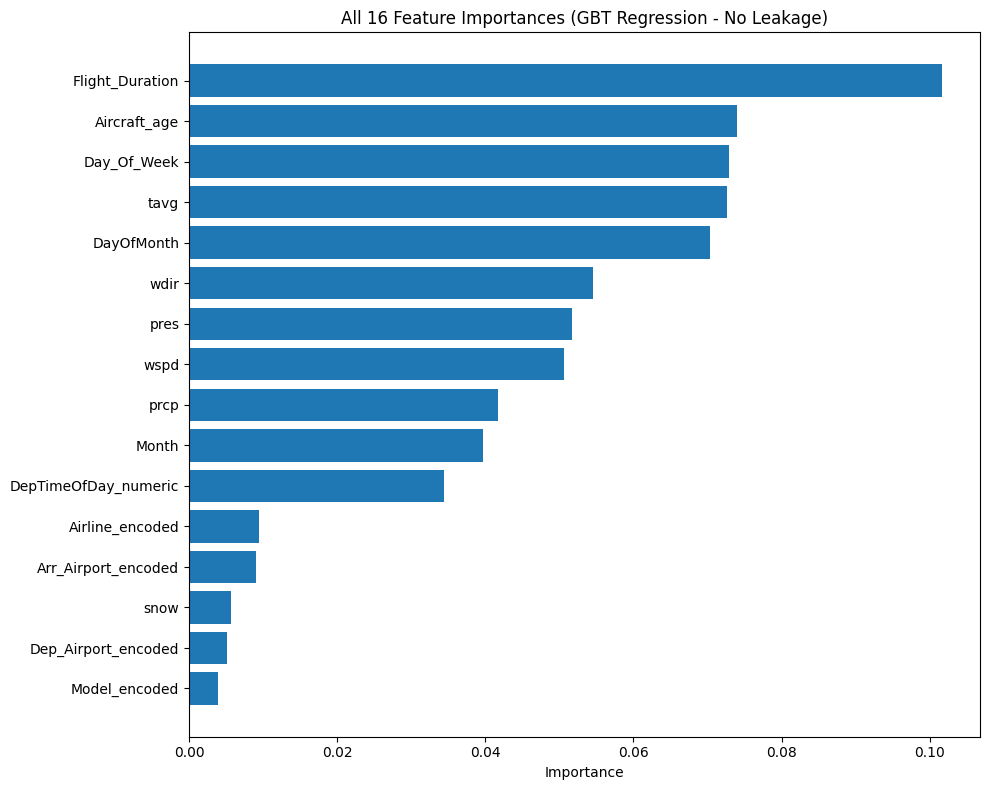


✅ Total features: 16
✅ Non-zero importances: 16
✅ Zero importances: 0


In [0]:
import pandas as pd
import matplotlib.pyplot as plt

print("=== Feature Importance Analysis (Gradient-Boosted Trees) ===")

# Get feature importances from the model
importances = gbt_model.featureImportances.toArray()

# Get feature names from the assembler
feature_names = assembler_clean.getInputCols()

print(f"\nDebug info:")
print(f"  Number of features: {len(feature_names)}")
print(f"  Number of importances: {len(importances)}")

# Ensure lengths match
if len(feature_names) != len(importances):
    print(f"\n⚠️ Length mismatch detected!")
    # Use the minimum length
    min_len = min(len(feature_names), len(importances))
    feature_names = feature_names[:min_len]
    importances = importances[:min_len]
    print(f"  Truncating to {min_len} features")

# Create DataFrame for easier visualization
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Display ALL features
print(f"\nAll {len(feature_importance_df)} Features (sorted by importance):")
print("=" * 60)
for idx, row in feature_importance_df.iterrows():
    print(f"{row['Feature']:<40} {row['Importance']:.6f}")

# Visualize ALL features
plt.figure(figsize=(10, max(8, len(feature_importance_df) * 0.4)))
plt.barh(range(len(feature_importance_df)), feature_importance_df['Importance'])
plt.yticks(range(len(feature_importance_df)), feature_importance_df['Feature'])
plt.xlabel('Importance')
plt.title(f'All {len(feature_importance_df)} Feature Importances (GBT Regression - No Leakage)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\n✅ Total features: {len(feature_names)}")
print(f"✅ Non-zero importances: {(importances > 0).sum()}")
print(f"✅ Zero importances: {(importances == 0).sum()}")

In [0]:
from pyspark.ml.feature import StandardScaler

print("=== Preparing Features for Linear Regression ===")
print("Note: Linear regression requires feature scaling\n")

# The feature vector is already assembled in train_data and test_data
# Now we need to scale the features

print("Fitting StandardScaler on training data...")
scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withMean=True,   # Center the data (mean = 0)
    withStd=True     # Scale to unit variance (std = 1)
)

# Fit the scaler on training data
scaler_model = scaler.fit(train_data_no_leak)

# Transform both train and test data
print("Scaling features...")
train_data_scaled_no_leak = scaler_model.transform(train_data_no_leak)
test_data_scaled_no_leak = scaler_model.transform(test_data_no_leak)

print(f"\n✅ Feature scaling complete!")
print(f"\nScaled feature column: 'scaled_features'")
print(f"Train data: {train_data_scaled_no_leak.count():,} rows")
print(f"Test data: {test_data_scaled_no_leak.count():,} rows")

# Display sample to show both original and scaled features
print("\n=== Sample (showing original and scaled features) ===")
display(train_data_scaled_no_leak.select("label", "features", "scaled_features").limit(3))

=== Preparing Features for Linear Regression ===
Note: Linear regression requires feature scaling

Fitting StandardScaler on training data...
Scaling features...

✅ Feature scaling complete!

Scaled feature column: 'scaled_features'
Train data: 1,071,316 rows
Test data: 267,812 rows

=== Sample (showing original and scaled features) ===


label features scaled_features 19 {"type":"0","size":"748","indices":["0","1","2","3","4","6","7","8","9","10","11","16","282","378","731"],"values":["1.0","127.0","21.0","16.0","10.4","27.0","14.5","1022.0","9.0","11.0","1.0","1.0","1.0","1.0","1.0"]} {"type":"1","size":null,"indices":null,"values":["-1.5406050924342023","-0.35488325053712316","0.9403322904527621","-0.17661543206271774","0.6106199861801475","-0.11993998252976229","-1.4687911875862203","0.28048543861487824","1.1827784138662392","0.8642792092927875","-0.5762895402991238","-0.112900609577168","-0.5342086938784834","-0.36025780159110593","-0.427796337952734","-0.34646432020069146","3.4415061364121025","-0.166600061438369","-0.2547878601242844","-0.24075587069932242","-0.18751240288551138","-0.1736379594148835","-0.14255975361071202","-0.1531283046760109","-0.20323763140571127","-0.14801599588986622","-0.11676935469530934","-0.2211611107328935","-0.2357571849334428","-0.22626318145255142","-0.20590962801899912","-0.18139823064048138","-0.16335228351515768","-0.19438137992700177","-0.15519397059679724","-0.15163720016647123","-0.18661707920888176","-0.1474519412703553","-0.15212928851672536","-0.13431275935748743","-0.1509367677281291","-0.14216730830038413","-0.14974537654263637","-0.12385586584009228","-0.11779585375735735","-0.13564988051490812","-0.11566382134615708","-0.14307014959437764","-0.11786914235399602","-0.13301040552341353","-0.11751451390674478","-0.11343059627601947","-0.1165021338901338","-0.14304976592390017","-0.12284193974344737","-0.10682284175020279","-0.1058667855319461","-0.09522404467784748","-0.0912982192887374","-0.09142806906448252","-0.08143613667862709","-0.08640503828455946","-0.079348464042478","-0.07725473259191419","-0.08046649834843245","-0.08465538839570598","-0.08065429995324898","-0.08004828082615406","-0.07372800045813797","-0.07718133560867539","-0.0685178108698342","-0.07333019760576986","-0.06864146393253186","-0.06926328312955969","-0.07136810008934144","-0.06742984767798425","-0.0795982388058789","-0.06650868836515662","-0.06065531835620981","-0.06398371986018013","-0.06822152721668441","-0.05706229747855944","-0.05659943004170246","-0.054390868859789464","-0.055332296404989025","-0.05181894650961393","-0.053634723937411415","-0.05114452770458129","-0.05659113058885533","-0.05110782178306202","-0.047403992006898044","-0.05291225956990128","-0.05330112712497584","-0.0527790435937947","-0.050461191309424655","-0.04720578568470322","-0.045434941280585166","-0.04798397339021204","-0.044612706501079104","-0.04179346672729447","-0.041534929364861216","-0.045103675681562705","-0.04425416929618108","-0.04049595166846162","-0.046171670912040275","-0.043721609979127635","-0.0470067510867864","-0.04447595734321402","-0.04071505635710037","-0.04371089312107129","-0.040472819470945894","-0.039901919208848086","-0.03619923302220628","-0.04116116775952872","-0.040077542742737025","-0.04378585646442377","-0.03891590357816898","-0.037966098042446925","-0.03789205578449446","-0.0393584853291047","-0.0393584853291047","-0.03639262074779108","-0.04144462790208565","-0.03340298776178238","-0.03713096093057649","-0.03432845756323889","-0.03733208515868118","-0.04049595166846162","-0.03426025191704127","-0.031142263488020527","-0.02949202752710384","-0.03045909479707756","-0.027439232142491332","-0.03250885474696248","-0.031142263488020527","-0.030520437794452515","-0.027010018330117597","-0.03150058548375704","-0.02446808502680861","-0.028574190989933638","-0.030320620980446612","-0.027061882362570747","-0.029681652134874285","-0.031928214080616295","-0.029932622881355973","-0.029317131311902965","-0.027524274116346146","-0.027216883211523508","-0.035991813516343125","-0.02510901917956032","-0.031884241537613635","-0.02396642470170138","-0.025679496252292083","-0.027302615685846687","-0.025127623304357662","-0.025515184504982864","-0.026958054809251168","-0.02365243509728963","-0.025053124123276625","-0.03005732522772942","-0.0268189946310472

In [0]:
from pyspark.ml.regression import LinearRegression
import time

print("=== Training Linear Regression Model ===")
start_time = time.time()

# Initialize Linear Regression
lr = LinearRegression(
    featuresCol="scaled_features",  # Use scaled features
    labelCol="label",
    maxIter=100,           # Maximum iterations
    regParam=0.1,          # L2 regularization parameter
    elasticNetParam=0.0,   # 0 = L2 (Ridge), 1 = L1 (Lasso), between = Elastic Net
    standardization=False  # We already scaled manually
)

# Train the model
lr_model = lr.fit(train_data_scaled_no_leak)
training_time = time.time() - start_time

print(f"✅ Training complete in {training_time:.2f} seconds")
print(f"\nModel details:")
print(f"  - Intercept: {lr_model.intercept:.2f}")
print(f"  - Number of features: {len(lr_model.coefficients)}")
print(f"  - Regularization: L2 (Ridge) with lambda={lr.getRegParam()}")

# Training summary
training_summary = lr_model.summary
print(f"\nTraining Summary:")
print(f"  - Total iterations: {training_summary.totalIterations}")
print(f"  - Objective history length: {len(training_summary.objectiveHistory)}")
print(f"  - RMSE: {training_summary.rootMeanSquaredError:.2f}")
print(f"  - R²: {training_summary.r2:.4f}")

=== Training Linear Regression Model ===
✅ Training complete in 51.76 seconds

Model details:
  - Intercept: 70.24
  - Number of features: 748
  - Regularization: L2 (Ridge) with lambda=0.1

Training Summary:
  - Total iterations: 31
  - Objective history length: 32
  - RMSE: 95.35
  - R²: 0.0323


In [0]:
print("=== Making Predictions with Linear Regression ===")

# Make predictions on train and test sets
lr_train_predictions = lr_model.transform(train_data_scaled_no_leak)
lr_test_predictions = lr_model.transform(test_data_scaled_no_leak)

print(f"✅ Predictions complete")

print("\n=== Linear Regression Model Evaluation ===")

# Evaluate on training set
lr_train_rmse = rmse_evaluator.evaluate(lr_train_predictions)
lr_train_mae = mae_evaluator.evaluate(lr_train_predictions)
lr_train_r2 = r2_evaluator.evaluate(lr_train_predictions)

print(f"\nTraining Set Performance:")
print(f"  RMSE: {lr_train_rmse:.2f} minutes")
print(f"  MAE:  {lr_train_mae:.2f} minutes")
print(f"  R²:   {lr_train_r2:.4f}")

# Evaluate on test set
lr_test_rmse = rmse_evaluator.evaluate(lr_test_predictions)
lr_test_mae = mae_evaluator.evaluate(lr_test_predictions)
lr_test_r2 = r2_evaluator.evaluate(lr_test_predictions)

print(f"\nTest Set Performance:")
print(f"  RMSE: {lr_test_rmse:.2f} minutes")
print(f"  MAE:  {lr_test_mae:.2f} minutes")
print(f"  R²:   {lr_test_r2:.4f}")

# Check for overfitting
print(f"\nOverfitting Check:")
print(f"  RMSE difference (train - test): {lr_train_rmse - lr_test_rmse:.2f}")
print(f"  R² difference (train - test): {lr_train_r2 - lr_test_r2:.4f}")

if lr_train_rmse < lr_test_rmse * 0.8:
    print("  ⚠️ Potential overfitting detected")
else:
    print("  ✅ Model generalizes well")

# Compare all four models
print(f"\n=== Model Comparison Summary ===")
print(f"\n{'Model':<20} {'Test RMSE':<15} {'Test MAE':<15} {'Test R²':<10}")
print("=" * 65)
print(f"{'Decision Tree':<20} {test_rmse:<15.2f} {test_mae:<15.2f} {test_r2:<10.4f}")
print(f"{'Random Forest':<20} {rf_test_rmse:<15.2f} {rf_test_mae:<15.2f} {rf_test_r2:<10.4f}")
print(f"{'Gradient Boosting':<20} {gbt_test_rmse:<15.2f} {gbt_test_mae:<15.2f} {gbt_test_r2:<10.4f}")
print(f"{'Linear Regression':<20} {lr_test_rmse:<15.2f} {lr_test_mae:<15.2f} {lr_test_r2:<10.4f}")

# Find best model
best_rmse = min(test_rmse, rf_test_rmse, gbt_test_rmse, lr_test_rmse)
best_r2 = max(test_r2, rf_test_r2, gbt_test_r2, lr_test_r2)

print(f"\n⭐ Best RMSE: {best_rmse:.2f} minutes")
print(f"⭐ Best R²: {best_r2:.4f}")

if lr_test_rmse == best_rmse and lr_test_r2 == best_r2:
    print(f"\n✅ Linear Regression is the best model!")

# Display sample predictions
print("\n=== Sample Predictions ===")
display(lr_test_predictions.select("label", "prediction").limit(10))

=== Making Predictions with Linear Regression ===
✅ Predictions complete

=== Linear Regression Model Evaluation ===

Training Set Performance:
  RMSE: 95.35 minutes
  MAE:  50.28 minutes
  R²:   0.0323

Test Set Performance:
  RMSE: 95.31 minutes
  MAE:  50.14 minutes
  R²:   0.0295

Overfitting Check:
  RMSE difference (train - test): 0.04
  R² difference (train - test): 0.0027
  ✅ Model generalizes well

=== Model Comparison Summary ===

Model                Test RMSE       Test MAE        Test R²   
Decision Tree        95.46           49.86           0.0266    
Random Forest        94.78           49.73           0.0366    
Gradient Boosting    95.16           49.47           0.0288    
Linear Regression    95.31           50.14           0.0295    

⭐ Best RMSE: 94.78 minutes
⭐ Best R²: 0.0366

=== Sample Predictions ===


label,prediction
25,43.19066930283339
19,80.00974211520867
19,67.2761956485878
28,66.54415873374165
16,77.66575115350828
19,90.87171810242228
27,71.93371792544494
23,83.12236475729553
26,86.28488965088594
30,54.71948614151256


# Classification
Will the flight be dealayed (1) or not (0)

In [0]:
train_df.printSchema()

root
 |-- Day_Of_Week: long (nullable = true)
 |-- Dep_Delay: long (nullable = true)
 |-- Arr_Delay: long (nullable = true)
 |-- Flight_Duration: long (nullable = true)
 |-- Delay_Carrier: long (nullable = true)
 |-- Delay_Weather: long (nullable = true)
 |-- Delay_NAS: long (nullable = true)
 |-- Delay_Security: long (nullable = true)
 |-- Delay_LastAircraft: long (nullable = true)
 |-- Aircraft_age: double (nullable = true)
 |-- tavg: double (nullable = true)
 |-- prcp: double (nullable = true)
 |-- snow: double (nullable = true)
 |-- wdir: double (nullable = true)
 |-- wspd: double (nullable = true)
 |-- pres: double (nullable = true)
 |-- Delayed (> 15 min): integer (nullable = false)
 |-- Month: integer (nullable = true)
 |-- DayOfMonth: integer (nullable = true)
 |-- DepTimeOfDay_numeric: integer (nullable = true)
 |-- Airline_encoded: vectorudt (nullable = true)
 |-- Dep_Airport_encoded: vectorudt (nullable = true)
 |-- Arr_Airport_encoded: vectorudt (nullable = true)
 |-- Model

In [0]:
from pyspark.sql.functions import col
train_df_classify = train_df.withColumnRenamed("Delayed (> 15 min)", "label") \
    .withColumn("label", col("label").cast("double"))

test_df_classify = test_df.withColumnRenamed("Delayed (> 15 min)", "label") \
    .withColumn("label", col("label").cast("double"))

In [0]:

# All ML spark.ml models require the feature input to be a feature vector, and a combined feature-label data instead of X_train and y_train directly 
from pyspark.ml.feature import VectorAssembler
assembler = VectorAssembler(inputCols=[c for c in train_df_classify.columns if c != 'label'], outputCol='features') 

all_feature_train_data = assembler.transform(train_df_classify) 
all_feature_test_data = assembler.transform(test_df_classify)

In [0]:
from pyspark.ml.classification import (DecisionTreeClassifier, LinearSVC, RandomForestClassifier, LogisticRegression)
from pyspark.sql.functions import col
from pyspark.sql.types import DoubleType

In [0]:
# ── Decision Tree ─────────────────────────────────────────────────────────
dt = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="label",
    maxDepth=9
)
dt_model = dt.fit(all_feature_train_data)

In [0]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    featuresCol="features", 
    labelCol="label", 
    numTrees=30, 
    maxDepth=10, 
    maxBins=32, 
    seed=42
)
rf_model = rf.fit(all_feature_train_data)

In [0]:
# ── Logistic Regression (StandardScaler applied first) ────────────────────
from pyspark.ml.feature import StandardScaler
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(all_feature_train_data)
all_feature_scaled_train = scaler_model.transform(all_feature_train_data)
all_feature_scaled_test  = scaler_model.transform(all_feature_test_data)

lr = LogisticRegression(featuresCol="scaled_features", labelCol="label", maxIter=100, regParam=0.01)
lr_model = lr.fit(all_feature_scaled_train)

In [0]:
# ── Linear SVC (StandardScaler features) ────────────────────
svm = LinearSVC(
    featuresCol="scaled_features",
    labelCol="label",
    maxIter=10,      
    regParam=0.1     
)

svm_model = svm.fit(all_feature_scaled_train)

In [0]:
# ── Define columns ────────────────────────────────────────────────────────
LABEL_COL = "Delayed (> 15 min)"

LEAKAGE_COLS = [
    "Arr_Delay",
    "Dep_Delay",
    "Delay_Carrier",
    "Delay_Weather",
    "Delay_NAS",
    "Delay_Security",
    "Delay_LastAircraft"
]

# ── Drop leakage columns & cast label to Double ───────────────────────────
train_clean = train_df.drop(*LEAKAGE_COLS).withColumn(LABEL_COL, col(LABEL_COL).cast(DoubleType()))
test_clean  = test_df.drop(*LEAKAGE_COLS).withColumn(LABEL_COL, col(LABEL_COL).cast(DoubleType()))

# ── Assemble feature vector ───────────────────────────────────────────────
assembler = VectorAssembler(
    inputCols=[c for c in train_clean.columns if c != LABEL_COL],
    outputCol="features",
    handleInvalid="skip",
)

feature_train = assembler.transform(train_clean)
feature_test  = assembler.transform(test_clean)


In [0]:
# ── Decision Tree ─────────────────────────────────────────────────────────
dt_no_delay = DecisionTreeClassifier(
    featuresCol="features",
    labelCol="Delayed (> 15 min)",
    maxDepth=9
)
dt_no_delay_model = dt_no_delay.fit(feature_train)

In [0]:
# ── Random Forest ─────────────────────────────────────────────────────────
rf_no_delay = RandomForestClassifier(
    featuresCol="features", 
    labelCol=LABEL_COL, 
    numTrees=30, 
    maxDepth=10, 
    maxBins=32, 
    seed=42
)
rf_no_delay_model = rf_no_delay.fit(feature_train)

In [0]:
# ── Logistic Regression (StandardScaler applied first) ────────────────────
scaler = StandardScaler(inputCol="features", outputCol="scaled_features", withStd=True, withMean=True)
scaler_model = scaler.fit(feature_train)
scaled_train = scaler_model.transform(feature_train)
scaled_test  = scaler_model.transform(feature_test)

lr_no_delay = LogisticRegression(featuresCol="scaled_features", labelCol=LABEL_COL, maxIter=100, regParam=0.01)
lr_no_delay_model = lr_no_delay.fit(scaled_train)

In [0]:
# ── Linear SVC (StandardSclar Features) ───────────────────────────────────────────────────
svm_no_delay = LinearSVC(
    featuresCol="scaled_features",
    labelCol=LABEL_COL,
    maxIter=10,
    regParam=0.1
)

svm_no_delay_model = svm_no_delay.fit(scaled_train)

In [0]:
# Define evaluator function
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

def evaluate_model(predictions, label_col, model_name):
    binary_eval = BinaryClassificationEvaluator(labelCol=label_col, rawPredictionCol="rawPrediction", metricName="areaUnderROC")
    multi_eval  = MulticlassClassificationEvaluator(labelCol=label_col, predictionCol="prediction")

    auc       = binary_eval.evaluate(predictions)
    accuracy  = multi_eval.evaluate(predictions, {multi_eval.metricName: "accuracy"})
    f1        = multi_eval.evaluate(predictions, {multi_eval.metricName: "f1"})
    precision = multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedPrecision"})
    recall    = multi_eval.evaluate(predictions, {multi_eval.metricName: "weightedRecall"})

    print(f"\n{'='*45}")
    print(f"  {model_name}")
    print(f"{'='*45}")
    print(f"  Accuracy  : {accuracy:.4f}")
    print(f"  F1        : {f1:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  AUC-ROC   : {auc:.4f}")
    print(f"{'='*45}")

    return {"model": model_name, "accuracy": round(accuracy, 4), "f1": round(f1, 4),
            "precision": round(precision, 4), "recall": round(recall, 4), "auc_roc": round(auc, 4)}


In [0]:
# ── TRAIN predictions ───────────────────────────────────────────────────
dt_train_all  = dt_model.transform(all_feature_train_data)
rf_train_all  = rf_model.transform(all_feature_train_data)
lr_train_all  = lr_model.transform(all_feature_scaled_train)
svm_train_all = svm_model.transform(all_feature_scaled_train)

dt_train_no_delay  = dt_no_delay_model.transform(feature_train)
rf_train_no_delay  = rf_no_delay_model.transform(feature_train)
lr_train_no_delay  = lr_no_delay_model.transform(scaled_train)
svm_train_no_delay = svm_no_delay_model.transform(scaled_train)

# ── TEST predictions ─────────────────────────────────────
dt_test_all  = dt_model.transform(all_feature_test_data)
rf_test_all  = rf_model.transform(all_feature_test_data)
lr_test_all  = lr_model.transform(all_feature_scaled_test)
svm_test_all = svm_model.transform(all_feature_scaled_test)

dt_test_no_delay  = dt_no_delay_model.transform(feature_test)
rf_test_no_delay  = rf_no_delay_model.transform(feature_test)
lr_test_no_delay  = lr_no_delay_model.transform(scaled_test)
svm_test_no_delay = svm_no_delay_model.transform(scaled_test)

In [0]:
# ── Helper to tag dataset type ──────────────────────────────────────────
def eval_with_split(preds, label_col, model_name, dataset_type, feature_type):
    res = evaluate_model(preds, label_col, model_name)
    res["dataset"] = dataset_type
    res["feature_type"] = feature_type
    return res


# ── ALL FEATURES ────────────────────────────────────────────────────────
results_all = [
    eval_with_split(dt_train_all, "label", "Decision Tree", "train", "all"),
    eval_with_split(dt_test_all,  "label", "Decision Tree", "test",  "all"),

    eval_with_split(rf_train_all, "label", "Random Forest", "train", "all"),
    eval_with_split(rf_test_all,  "label", "Random Forest", "test",  "all"),

    eval_with_split(lr_train_all, "label", "Logistic Regression", "train", "all"),
    eval_with_split(lr_test_all,  "label", "Logistic Regression", "test",  "all"),

    eval_with_split(svm_train_all, "label", "Linear SVM", "train", "all"), 
    eval_with_split(svm_test_all, "label", "Linear SVM", "test", "all"),
]


# ── NO DELAY FEATURES ───────────────────────────────────────────────────
results_no_delay = [
    eval_with_split(dt_train_no_delay, LABEL_COL, "Decision Tree", "train", "no_delay"),
    eval_with_split(dt_test_no_delay,  LABEL_COL, "Decision Tree", "test",  "no_delay"),

    eval_with_split(rf_train_no_delay, LABEL_COL, "Random Forest", "train", "no_delay"),
    eval_with_split(rf_test_no_delay,  LABEL_COL, "Random Forest", "test",  "no_delay"),

    eval_with_split(lr_train_no_delay, LABEL_COL, "Logistic Regression", "train", "no_delay"),
    eval_with_split(lr_test_no_delay,  LABEL_COL, "Logistic Regression", "test",  "no_delay"),

    eval_with_split(svm_train_no_delay, LABEL_COL, "Linear SVM", "train", "no_delay"), 
    eval_with_split(svm_test_no_delay, LABEL_COL, "Linear SVM", "test", "no_delay"),
]


# ── Combine & Display ───────────────────────────────────────────────────
import pandas as pd

final_results = results_all + results_no_delay
spark.createDataFrame(pd.DataFrame(final_results)).orderBy("model", "feature_type", "dataset").show(truncate=False)


  Decision Tree
  Accuracy  : 0.9977
  F1        : 0.9977
  Precision : 0.9977
  Recall    : 0.9977
  AUC-ROC   : 0.9999

  Decision Tree
  Accuracy  : 0.9977
  F1        : 0.9977
  Precision : 0.9978
  Recall    : 0.9977
  AUC-ROC   : 0.9999

  Random Forest
  Accuracy  : 0.9819
  F1        : 0.9816
  Precision : 0.9820
  Recall    : 0.9819
  AUC-ROC   : 0.9995

  Random Forest
  Accuracy  : 0.9821
  F1        : 0.9819
  Precision : 0.9823
  Recall    : 0.9821
  AUC-ROC   : 0.9995

  Logistic Regression
  Accuracy  : 0.9634
  F1        : 0.9620
  Precision : 0.9649
  Recall    : 0.9634
  AUC-ROC   : 0.9995

  Logistic Regression
  Accuracy  : 0.9635
  F1        : 0.9620
  Precision : 0.9650
  Recall    : 0.9635
  AUC-ROC   : 0.9995

  Linear SVM
  Accuracy  : 0.9347
  F1        : 0.9296
  Precision : 0.9396
  Recall    : 0.9347
  AUC-ROC   : 0.9995

  Linear SVM
  Accuracy  : 0.9349
  F1        : 0.9298
  Precision : 0.9398
  Recall    : 0.9349
  AUC-ROC   : 0.9995

  Decision Tree
 

In [0]:
dbutils.library.restartPython()